## Explore pairwise epistasis with DASM
Can we predict epistasis using DASM?
Traditional epistasis calculation requires measuring all mutation combinations and modeling fitness as individual effects plus interactions.
DASM offers a direct approach: we mutate each position to all possible amino acids and measure the resulting selection factors at every position. This reveals epistatic interactions without modeling, as we directly observe how mutations at one position affect selection factors at others.

From a starting sequence, we mutated every position into every possible amino acid and measured all of the selection factors.
How do we decide if the change we measure is significant? We run into the same problem as with uncertainty estimations - the change in selection factors is correlated with the original selection factors. I tried 3 ways to quantify the changes:
- Simply take the difference between the new selection factor and the original. If I am aggregating more than one measurement by summing, I take the absolute difference. I use log selection factors throughout as these are easier to compare (-1 and 1 are opposite, instead of 0.5 and 2). This is not the best measure it is correlated with the original prediction - more extreme predictions have more variation in them.
- Count the number of times we get a change from purifying selection to diversifying, or a "sign flip" (from + to - or opposite). I also added a condition that the absolute change has to be more than 0.1 as to not count tiny changes around neutral. Th
- Modified z score of the measured selection factor, calculated per measured position and amino acid group. Assuming most other mutations do not interact epistatically with a specific position, then the distribution of the measurementsover all the perturbations should be a background noise distribution.
To find outliers that may be epistatic interaction, we use the modified z score, which used the median and is thus less affected by large outliers but can still identify them.

I ran this analysis on the Koenig dataset, just to get some general distributions of the data. As suspected, the modified z score is the only measure that is not correlated with the origianl prediction, making it a good bet for finding outliers.

Next, I ran this analysis on two sequences for which we have some experimental measurements - the Phillips and Schulz sequences (https://elifesciences.org/articles/83628, https://www.pnas.org/doi/10.1073/pnas.2413884122).

We see some possible agreement between the experimental measurements in the paper and our epistasis predictions, but doesn't seem significant. This could be too big an ask for the DASM model bacause:
- Our model is antigen agnostic and the Phillips measurements are not
- The model needed to see very large datasets to be able to infer specific interactions of two specific positions across a specific genetic background.

Some nice biological results are that in the Schulz sequence, we see some epistasis signals within each CDR, which makes biological sense. We also see a few other pairs of positions popping up that we cannot necassirily explain. If going back to this, I'd explore the CDR and FWK relationship across more sequences.

In [1]:
import os

import matplotlib.pyplot as plt
import matplotlib
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from scipy import stats
import os
from matplotlib import colors, ticker
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from scipy import stats
import tqdm

import sys
sys.path.append('../dnsm-experiments-1/')

from netam.common import heavy_chain_shim
from netam.framework import load_crepe
from netam.sequences import translate_sequence, AA_STR_SORTED
from dnsmex.dasm_viz import dms_style_heatmap
from dnsmex.local import localify
from dnsmex.koenig_helper import KoenigDataset, plot_variant_comparison
from netam.sequences import (AA_STR_SORTED)
from dnsmex.dasm_mc_dropout import run_mc_dropout_on_heavy_seq, calc_mc_dropout_stats_per_seq


figures_dir = localify("FIGURES_DIR")
os.makedirs("_output", exist_ok=True)

# set mpl font to lato
#plt.rcParams["font.family"] = "Lato"

In [2]:
import warnings
import numpy as np

# Filter out the specific NumPy deprecation warning about __array_wrap__
warnings.filterwarnings("ignore", category=DeprecationWarning, 
                       message="__array_wrap__ must accept context and return_scalar")


In [3]:
heavy_wt = "EVQLVESGGGLVQPGGSLRLSCAASGFTISDYWIHWVRQAPGKGLEWVAGITPAGGYTYYADSVKGRFTISADTSKNTAYLQMNSLRAEDTAVYYCARFVFFLPYAMDYWGQGTLVTVSS"

In [4]:
def assign_wt(df, wt_seq, value):
    for idx, aa in enumerate(wt_seq):
        df.loc[aa, idx+1] = value

def df_of_arr(arr):
    return pd.DataFrame(arr, columns=range(1, arr.shape[1] + 1), index=list(AA_STR_SORTED))

In [5]:
# Load DASM model
crepe = load_crepe(localify("DASM_TRAINED_MODELS_DIR/dasm_4m-v1jaffeCC+v1tangCC-joint"))
#crepe.model.train()
crepe = heavy_chain_shim(crepe)


In [6]:
def zero_centered_cb_min_center_max(df):
    data_min = df.min().min()
    data_max = df.max().max()
    assert data_min < 0 and data_max > 0
    return data_min, 0, data_max

def make_heatmap(df, ax, colorbar_label):
    _ = dms_style_heatmap(
        df, 
        ax=ax, 
        cb_min_center_max=zero_centered_cb_min_center_max(df), 
        plot_aa_order=list("YWFLIVAMKRHDESTNQPGC"),
        colorbar_label=colorbar_label)

# Mutate sequence and measure predictions to find epistasis

EVQLVESGGGLVQPGGSLRLSCAASGFTISDYWIHWVRQAPGKGLEWVAGITPAGGYTYYADSVKGRFTISADTSKNTAYLQMNSLRAEDTAVYYCARFVFFLPYAMDYWGQGTLVTVSS
EVQLVESGGGLVQPGGSLRLSCAASGFTISDYWIHWVRQAPGKGLEWVAGITPAGGYTYYADSVKGRFTISADTSKNTAYLQMNSLRAEDTAVYYCARFVFFLPYAMDYWGQGTLVTVSS


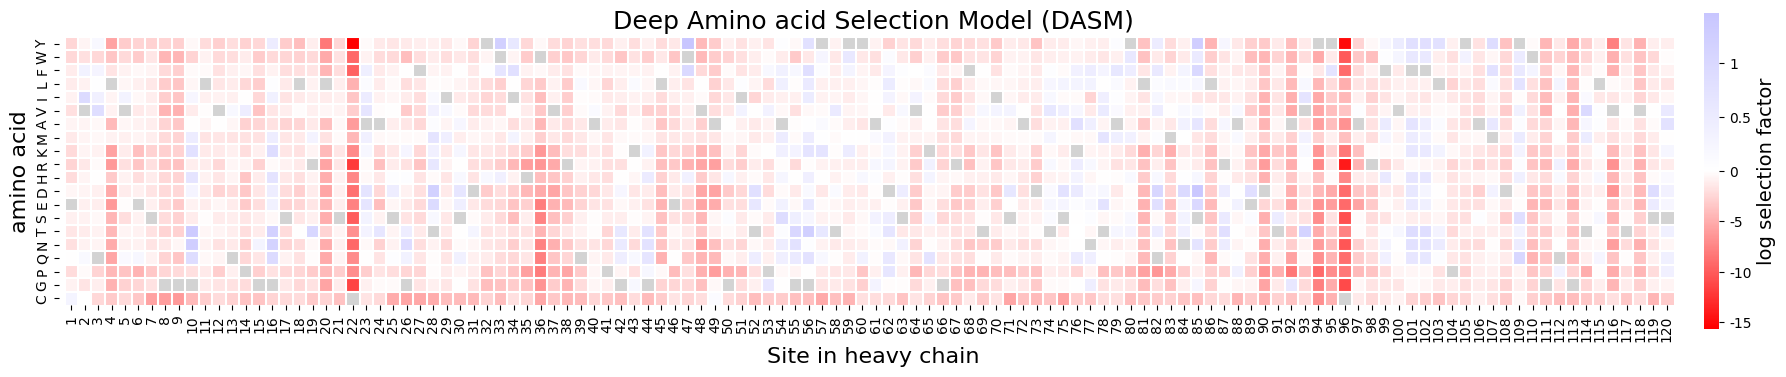

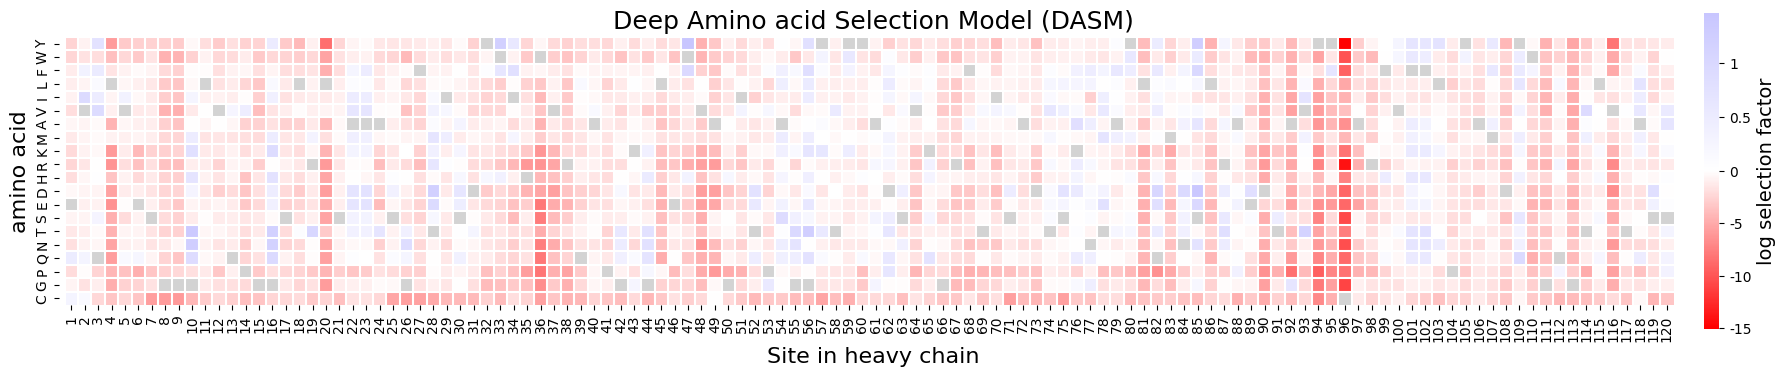

In [7]:
#### Example - two slightly different sequences results in different selection factors


[dasm_heavy] = crepe([heavy_wt])
log_dasm_heavy = np.log(dasm_heavy).T
log_dasm_heavy_df = df_of_arr(log_dasm_heavy)
assign_wt(log_dasm_heavy_df, heavy_wt, np.nan)

fig, ax = plt.subplots(1, 1, figsize=(18, 4))

print(heavy_wt)

make_heatmap(log_dasm_heavy_df, ax, "log selection factor")
ax.set_title('Deep Amino acid Selection Model (DASM)', fontsize=18)
ax.set_xlabel('Site in heavy chain', fontsize=16)
ax.set_ylabel('amino acid', fontsize=16)
plt.tight_layout()



[dasm_heavy] = crepe(['EVQLVESGGGLVQPGGSLRLSAAASGFTISDYWIHWVRQAPGKGLEWVAGITPAGGYTYYADSVKGRFTISADTSKNTAYLQMNSLRAEDTAVYYCARFVFFLPYAMDYWGQGTLVTASS'])
log_dasm_heavy = np.log(dasm_heavy).T
log_dasm_heavy_df = df_of_arr(log_dasm_heavy)
assign_wt(log_dasm_heavy_df, 'EVQLVESGGGLVQPGGSLRLSAAASGFTISDYWIHWVRQAPGKGLEWVAGITPAGGYTYYADSVKGRFTISADTSKNTAYLQMNSLRAEDTAVYYCARFVFFLPYAMDYWGQGTLVTASS', np.nan)

fig, ax = plt.subplots(1, 1, figsize=(18, 4))

print(heavy_wt)

make_heatmap(log_dasm_heavy_df, ax, "log selection factor")
ax.set_title('Deep Amino acid Selection Model (DASM)', fontsize=18)
ax.set_xlabel('Site in heavy chain', fontsize=16)
ax.set_ylabel('amino acid', fontsize=16)
plt.tight_layout()

### Run single mutation analysis

In [8]:


def calculate_modified_z_scores(df, group_columns, value_column):
    """
    Calculate modified z-scores within groups and add to the dataframe
    """
    # Create a copy of the dataframe
    result_df = df.copy()
    # Define function to calculate modified z-score for a group
    def mod_zscore(group):
        # Calculate median of the group
        median = group.median()
        # Calculate median absolute deviation (MAD)
        mad = np.median(np.abs(group - median))
        # Handle zero MAD case to avoid division by zero
        if mad == 0:
            return pd.Series(0, index=group.index)
        # Calculate modified z-score
        return 0.6745 * (group - median) / mad
    # Apply the function to each group
    result_df[f'{value_column}_mod_zscore'] = result_df.groupby(group_columns)[value_column].transform(mod_zscore)
    return result_df



def run_model_mutating_seq(start_seq, device='cpu'):
    '''
    This function iterates across all positions in the sequence and mutates each position to all possible amino acids.
    It then runs the model on the mutated sequence and returns a dataframe with the results.
    '''
    crepe = load_crepe(localify("DASM_TRAINED_MODELS_DIR/dasm_4m-v1jaffeCC+v1tangCC-joint"), device=device)
    crepe = heavy_chain_shim(crepe)
    
    # original seq
    [dasm_heavy] = crepe([start_seq])
    log_dasm_heavy = np.log(dasm_heavy).T
    log_dasm_heavy_df = df_of_arr(log_dasm_heavy)
    assign_wt(log_dasm_heavy_df, start_seq, np.nan)
    log_dasm_heavy_df_long = log_dasm_heavy_df.stack().reset_index()
    log_dasm_heavy_df_long.columns = ['AminoAcid', 'Position', 'log_selection_factor']
    original_predictions = log_dasm_heavy_df_long.copy()

    # mutate seq and get predictions
    all_predictions = []

    for pos in tqdm.tqdm(range(1, len(start_seq) + 1)):
        for aa in AA_STR_SORTED:
            seq = start_seq[:pos-1] + aa + start_seq[pos:]
            [dasm_heavy] = crepe([seq])
            log_dasm_heavy = np.log(dasm_heavy).T
            log_dasm_heavy_df = df_of_arr(log_dasm_heavy)
            assign_wt(log_dasm_heavy_df, seq, np.nan)
            log_dasm_heavy_df_long = log_dasm_heavy_df.stack().reset_index()
            log_dasm_heavy_df_long.columns = ['AminoAcid', 'Position', 'log_selection_factor']

            log_dasm_heavy_df_long['mut_from_origin'] = start_seq[pos-1] + str(pos) + aa
            log_dasm_heavy_df_long['mut_from_origin_pos'] = pos
            log_dasm_heavy_df_long['mut_from_origin_end_aa'] = aa
            log_dasm_heavy_df_long['mut_from_origin_start_aa'] = start_seq[pos-1]


            all_predictions.append(log_dasm_heavy_df_long)

    # Combine all samples
    all_data = pd.concat(all_predictions, ignore_index=True)

    # add original predictions as comparison
    all_data = pd.merge(all_data, original_predictions, on=['AminoAcid', 'Position'], suffixes=('', '_original'), how='left')

    # add selection factor diff - if + it increased, if - it decreased
    all_data['log_selection_factor_diff'] =  all_data.log_selection_factor - all_data.log_selection_factor_original
    # absulute selection factor diff
    all_data['log_selection_factor_diff_abs'] =  np.abs(all_data['log_selection_factor_diff'])

    # add selection factor ratio - 
    all_data['log_selection_factor_ratio'] =  all_data.log_selection_factor / all_data.log_selection_factor_original 
    # add if there is a flip for diversyfying to purifying and the other way around
    all_data['div_pur_flip'] = (all_data['log_selection_factor'] * all_data['log_selection_factor_original'] < 0)
    
    # add modified z score per measured amino acid and position - assumes most nmeasurements per position are not epistatic, and as such only outliers are epistatic
    all_data = calculate_modified_z_scores(all_data, ['AminoAcid', 'Position'], 'log_selection_factor')
    all_data['log_selection_factor_mod_zscore_abs'] = all_data['log_selection_factor_mod_zscore'].abs()

    return all_data




In [9]:
### plot heatmap of log selection factor differences per specific mutation

ORDERED_INDEX = list("YWFLIVAMKRHDESTNQPGC")

def plot_dasm_heatmap_predictions(seq):
    [dasm_heavy] = crepe([seq])
    log_dasm_heavy = np.log(dasm_heavy).T
    log_dasm_heavy_df = df_of_arr(log_dasm_heavy)
    assign_wt(log_dasm_heavy_df, seq, np.nan)
    fig, ax = plt.subplots(1, 1, figsize=(18, 4))
    make_heatmap(log_dasm_heavy_df, ax, "log selection factor")
    ax.set_title('Deep Amino acid Selection Model (DASM)', fontsize=18)
    ax.set_xlabel('Site in heavy chain', fontsize=16)
    ax.set_ylabel('amino acid', fontsize=16)
    plt.tight_layout()
    plt.show()

def plot_log_heatmap_epistasis(all_data, mutation, measure_to_plot,title='log_selection_factor_diff', original_seq=False, vmin=-1.5, vmax=1.5):
    if original_seq:
        plot_dasm_heatmap_predictions(original_seq)
        plot_dasm_heatmap_predictions(original_seq[:int(mutation[1:-1])-1] + mutation[-1] + original_seq[int(mutation[1:-1]):])   
    
    f, ax = plt.subplots(figsize=(20, 4)) 
    cur_data = all_data[(all_data.mut_from_origin == mutation) & (all_data.Position != int(mutation[1:-1]))].copy()
    cur_data_np = all_data[(all_data.mut_from_origin == mutation) & (all_data.Position == int(mutation[1:-1]))].copy()
    cur_data_np['log_selection_factor_diff'] = np.nan
    cur_data = pd.concat([cur_data, cur_data_np], ignore_index=True)
    cur_data = cur_data.pivot(index='AminoAcid', columns='Position', values=measure_to_plot)
    cur_data = cur_data.reindex(ORDERED_INDEX)

    # Set vmin and vmax symmetrically for the coolwarm colormap
    p = sns.heatmap(cur_data, cmap='coolwarm', ax=ax, xticklabels=True, yticklabels=True, 
                   cbar=True, center=0, vmin=vmin, vmax=vmax, linecolor='white', linewidths=0.5)
    ax.set_title(title, fontsize=18)
    ax.set_xlabel("Site in heavy chain", fontsize=16)
    ax.set_ylabel("Amino acid", fontsize=16)
    plt.tight_layout()
    plt.show()

def plot_scatter_epistasis(all_data, mutation):
    # Filter data
    cur_data = all_data[(all_data.mut_from_origin == mutation) & (all_data.Position != int(mutation[1:-1]))].copy()
    
    # Create figure
    plt.figure(figsize=(6, 4))
    
    # Create scatter plot with better styling
    plt.scatter(data=cur_data[cur_data['div_pur_flip'] == False], x = 'log_selection_factor_original', y= 'log_selection_factor', alpha=0.7, s=50, c='royalblue', edgecolor='white', label='same_sign')
    plt.scatter(data=cur_data[cur_data['div_pur_flip'] == True], x = 'log_selection_factor_original', y='log_selection_factor', alpha=0.7, s=50, c='red', edgecolor='white', label='flip sign')


    # Add identity line
    min_val = min(cur_data['log_selection_factor_original'].min(), cur_data['log_selection_factor'].min())
    max_val = max(cur_data['log_selection_factor_original'].max(), cur_data['log_selection_factor'].max())
    
    # Improve labels and title
    plt.xlabel('Original Log Selection Factor', fontsize=12)
    plt.ylabel('Log Selection Factor', fontsize=12)
    plt.title(f"Mutation: {mutation}", fontsize=14, fontweight='bold')
    
    # Add grid and style improvements
    plt.grid(alpha=0.3)
    plt.tight_layout()
    
    # Optional: Calculate correlation
    corr = cur_data['log_selection_factor_original'].corr(cur_data['log_selection_factor'])
    plt.annotate(f'Correlation: {corr:.3f}', 
                xy=(0.05, 0.95), 
                xycoords='axes fraction',
                bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.8))
    
    return plt.gca()

def print_epistatics_measurement_summary(all_data, mut):
    cur_data = all_data[(all_data.mut_from_origin == mut) & (all_data.Position != int(mut[1:-1]))].copy()
    print('Positions showing a flip in selection factor:')
    print(cur_data[cur_data['div_pur_flip'] == True].sort_values('log_selection_factor_diff_abs', ascending=False)[['Position', 'AminoAcid', 'log_selection_factor', 'log_selection_factor_original']].head(n=20))
    print('Positions with the highest sum of absolute predictions diffs')
    print(cur_data.groupby('Position').log_selection_factor_diff_abs.sum().sort_values(ascending=False).head(n=10))



In [10]:
# koenig data
heavy_wt = "EVQLVESGGGLVQPGGSLRLSCAASGFTISDYWIHWVRQAPGKGLEWVAGITPAGGYTYYADSVKGRFTISADTSKNTAYLQMNSLRAEDTAVYYCARFVFFLPYAMDYWGQGTLVTVSS"
output_path = localify("DATA_DIR/epistasis/dasm_mutate_run/koenig.csv")

if not os.path.exists(output_path):
    all_data = run_model_mutating_seq(heavy_wt, device='cuda')
    all_data.to_csv(output_path, index=False)

all_data = pd.read_csv(output_path)


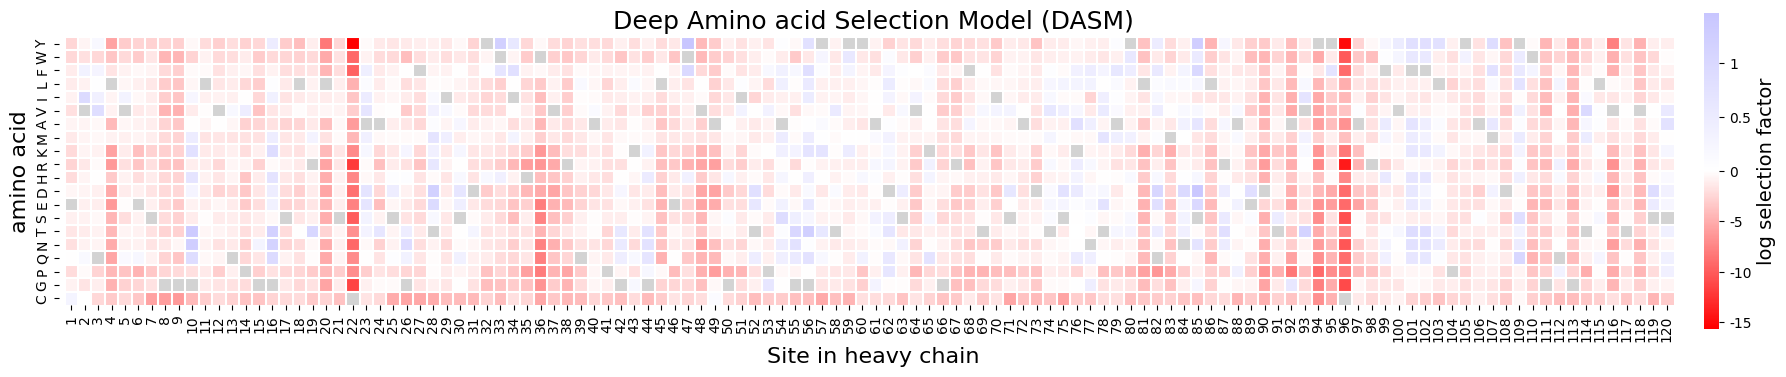

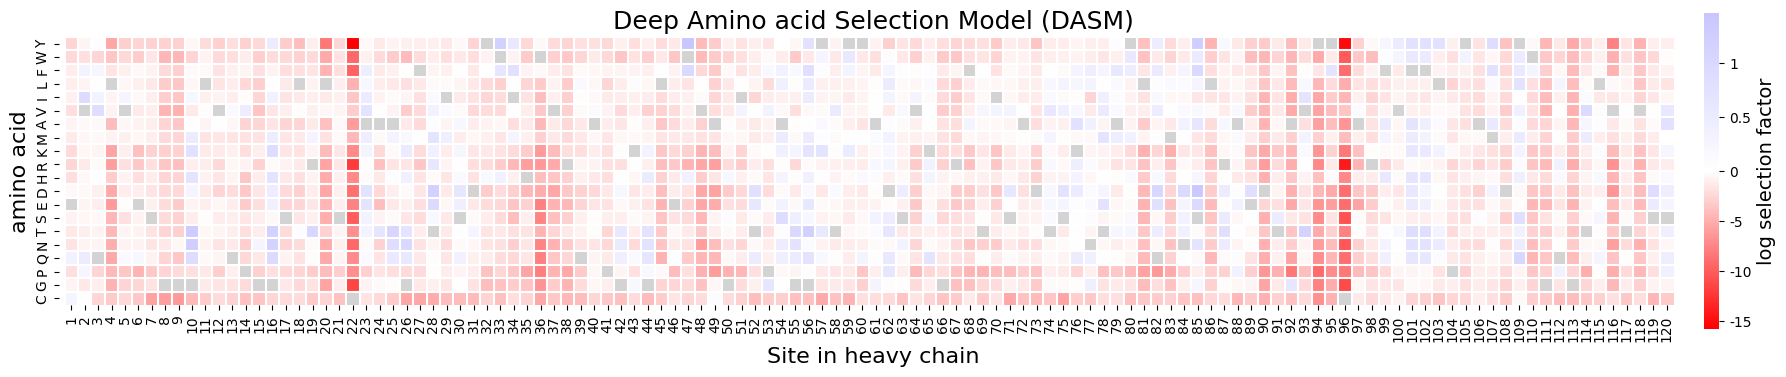

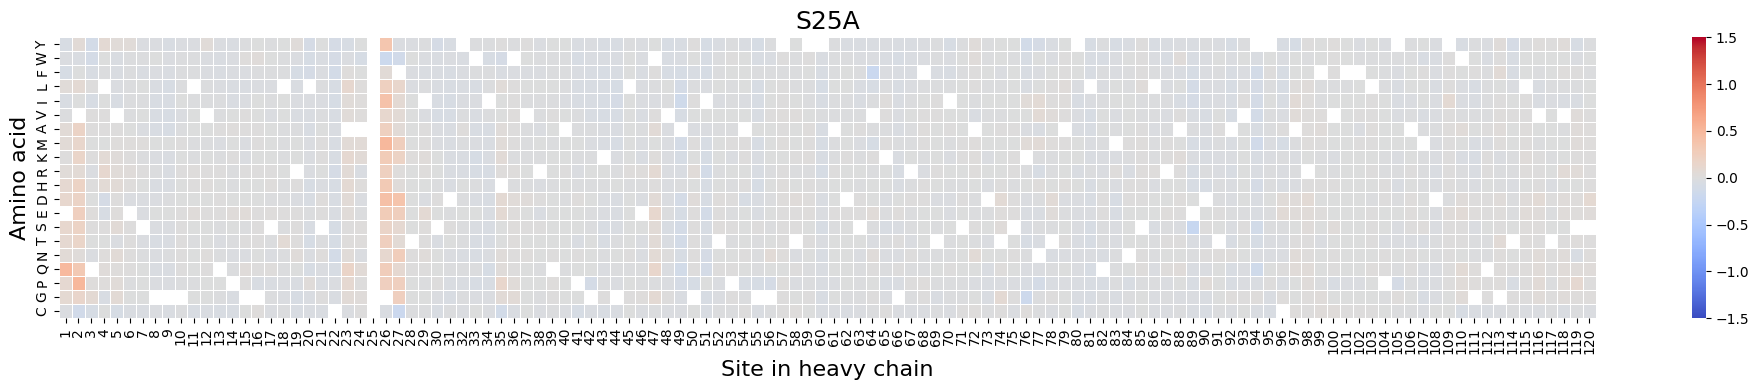

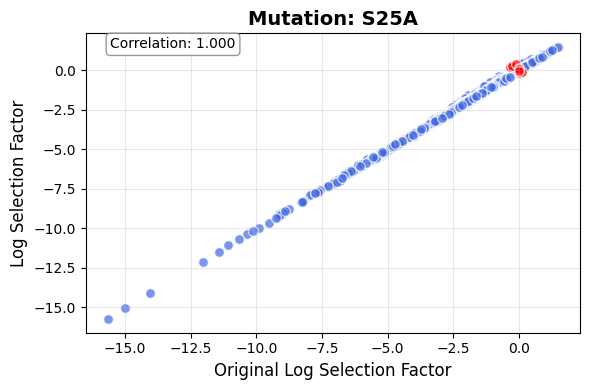

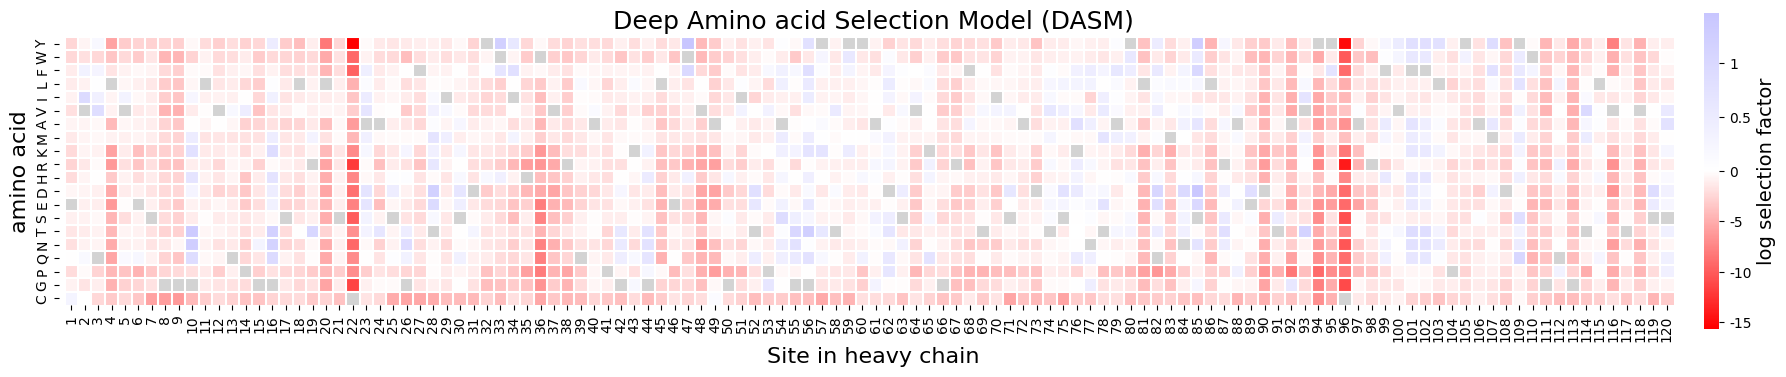

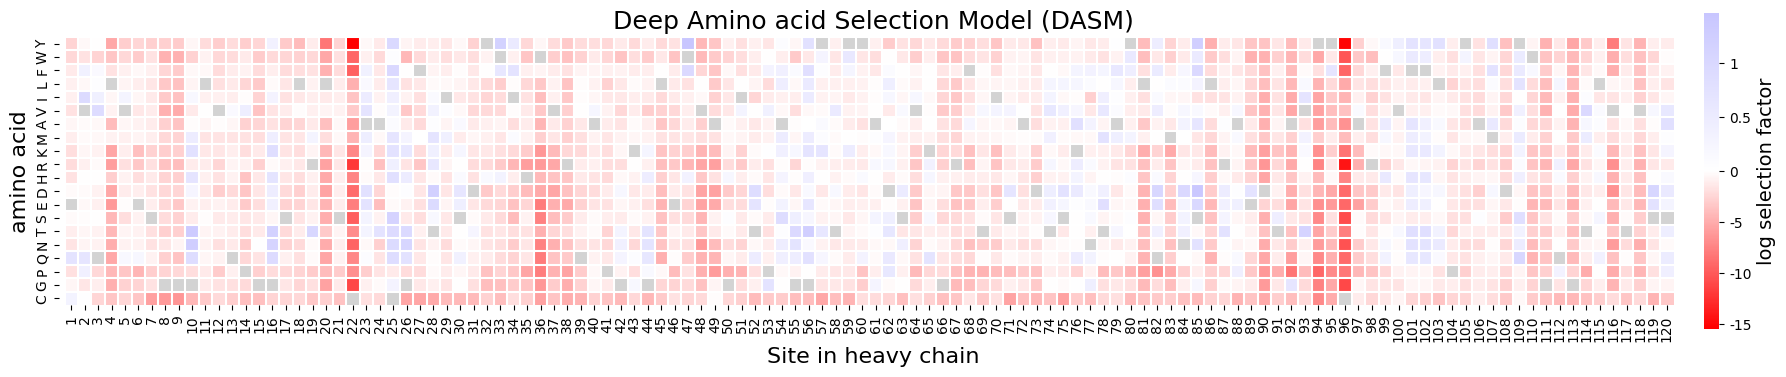

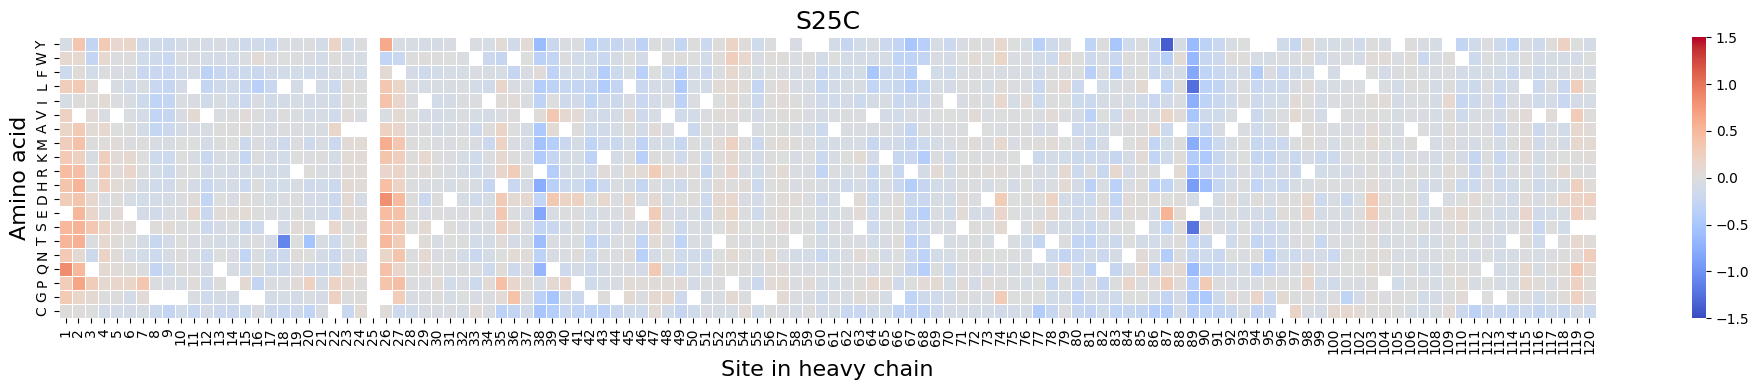

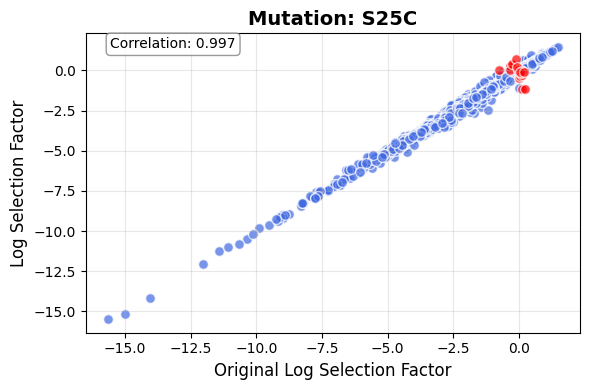

In [11]:
## how does the data look?


for mut in ['S25A', 'S25C']:
    plot_log_heatmap_epistasis(all_data, mut, 'log_selection_factor_diff', title=mut, original_seq=heavy_wt)
    plot_scatter_epistasis(all_data, mut)




## general exploration of distributions - is there correlation between log selection factors and prediction diff?
yes - although not as pronounced as mc dropout..
Still, we need to figure out how to normalize this/look at this differently so that we can make inferences of epistasis on it:
 - sign flip (diversifying to puryifying and opposite) - only true/false per pair, and then can aggregate.

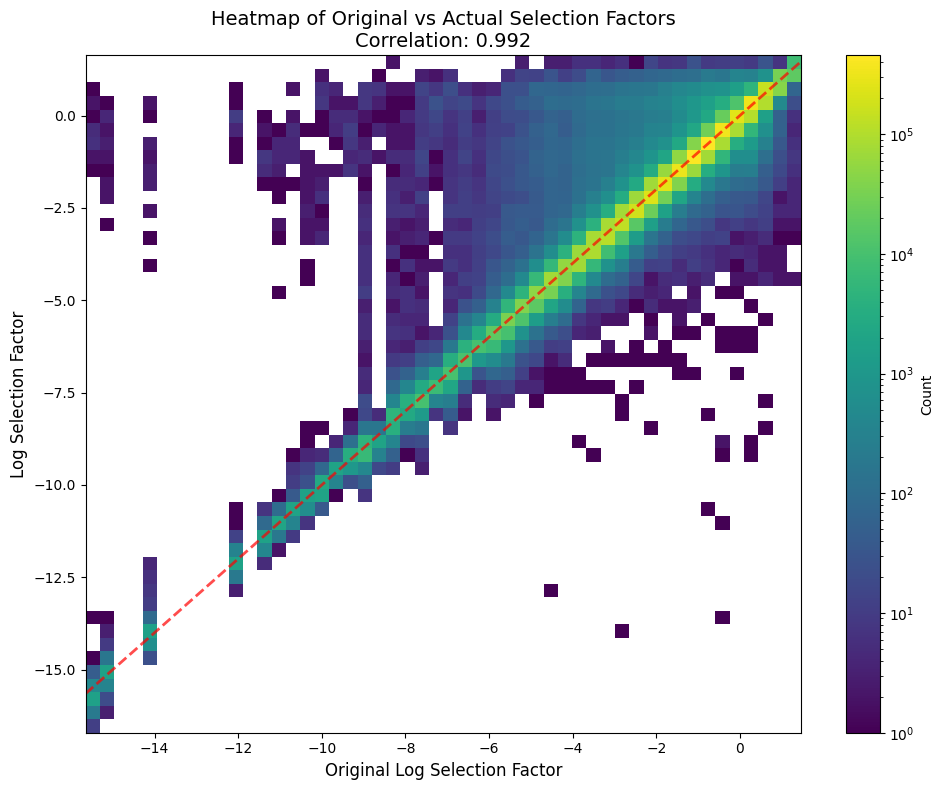

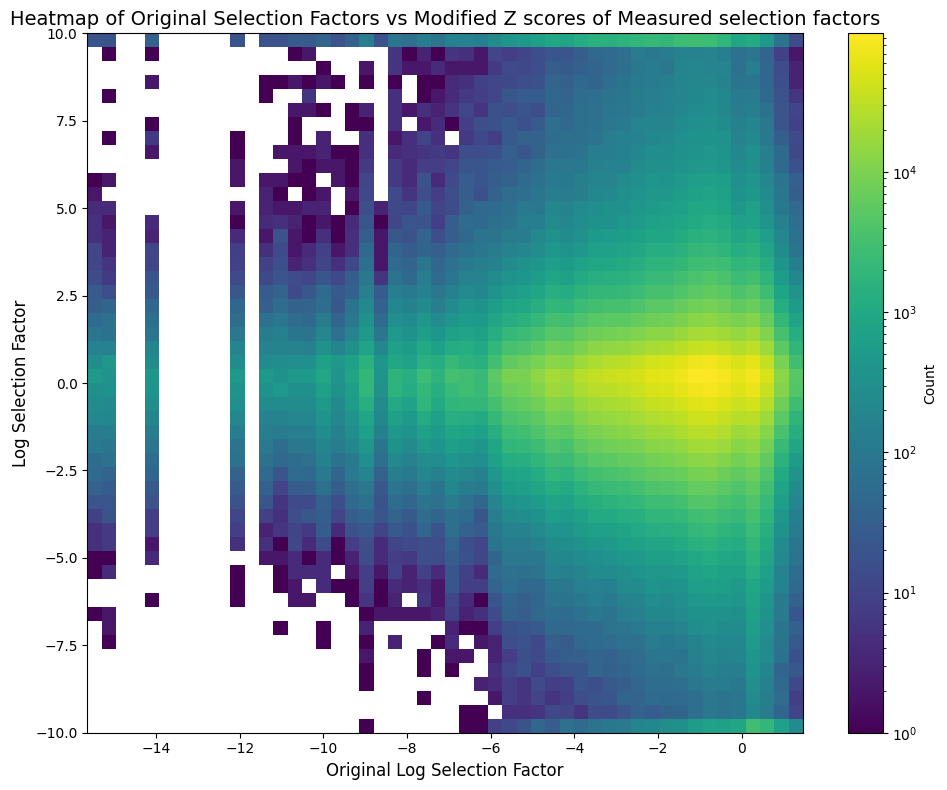

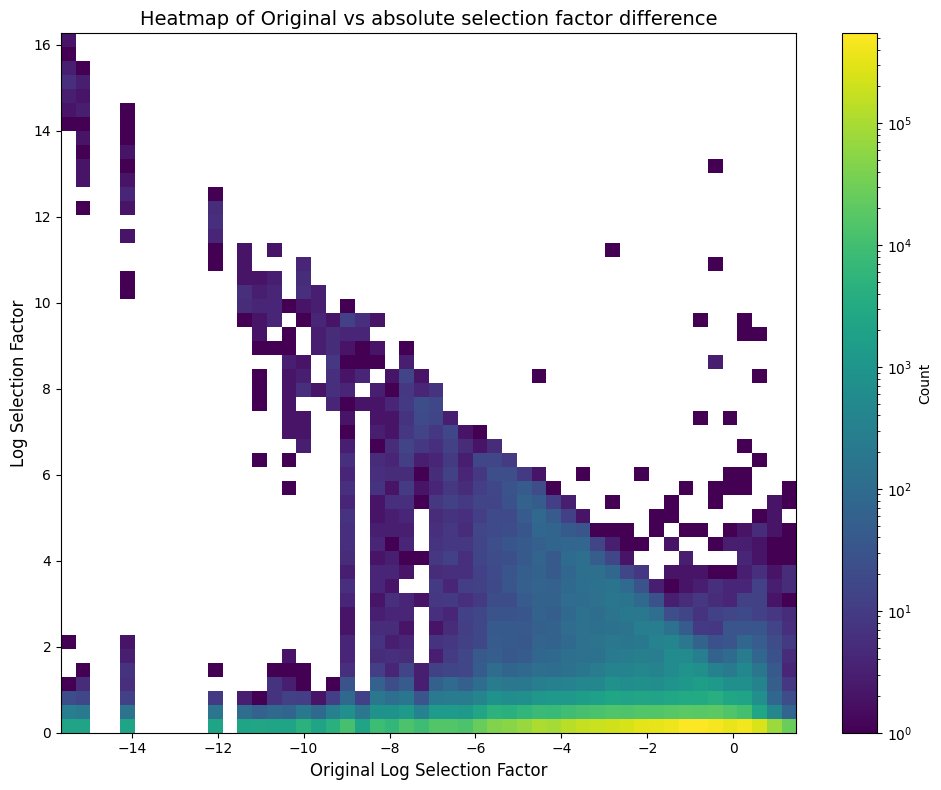

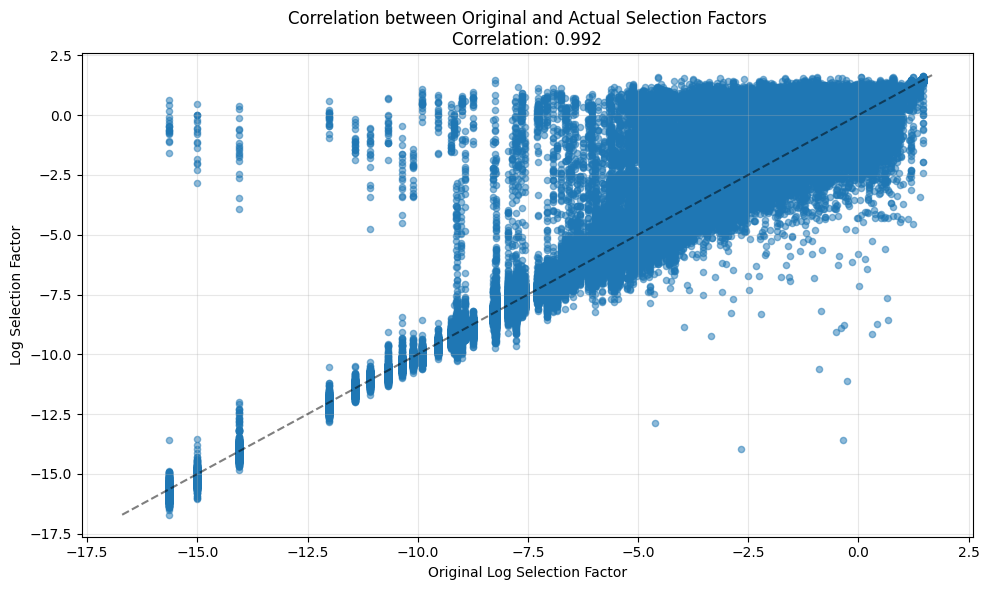

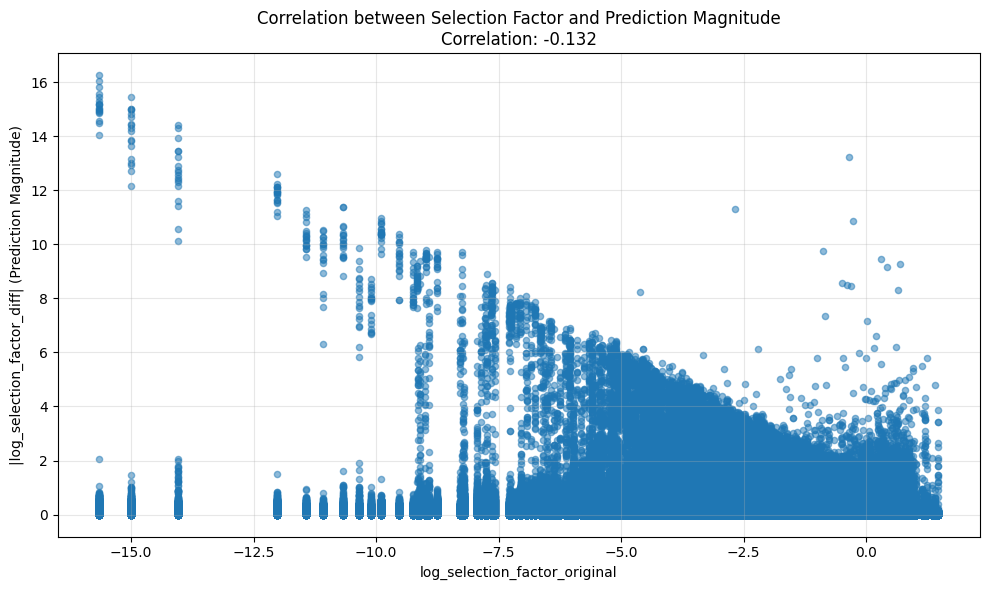

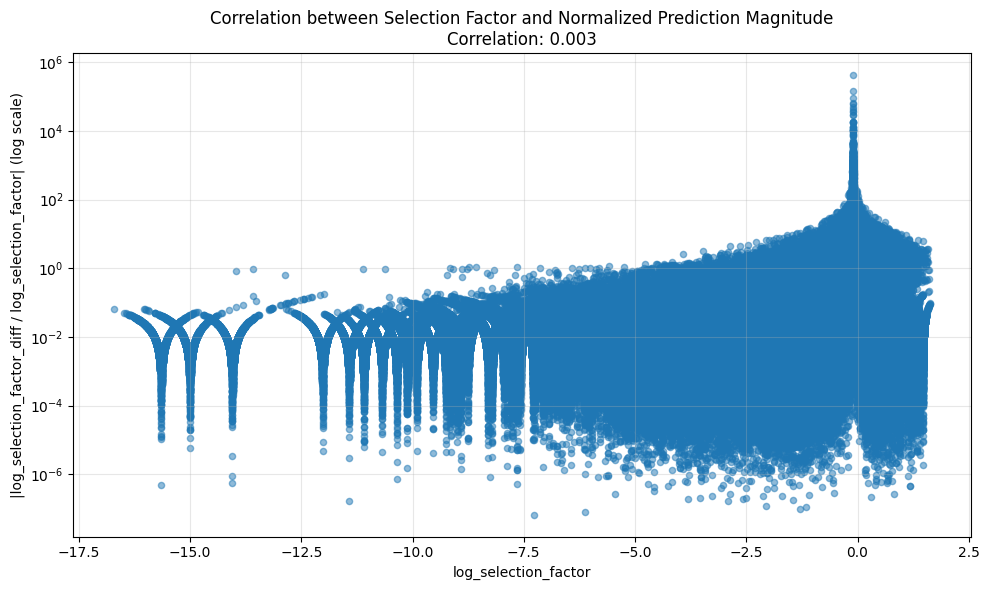

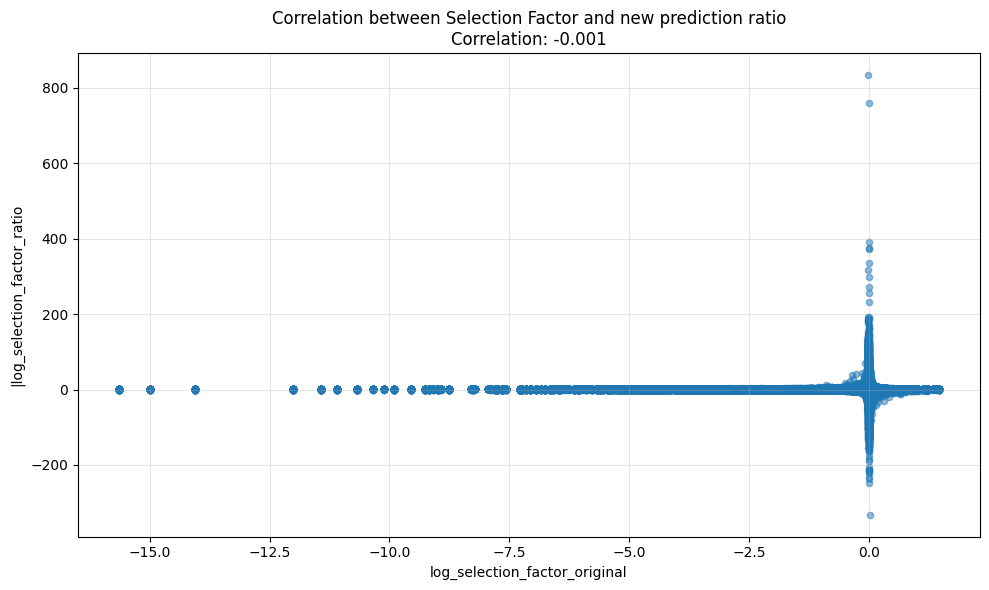

In [12]:

def plot_selection_factor_correlation(data):
    # Create a scatter plot
    plt.figure(figsize=(10, 6))
    plt.scatter(data['log_selection_factor_original'], data['log_selection_factor'], 
                alpha=0.5, s=20)
    
    # Calculate correlation (only if there are valid, non-NaN values)
    mask = ~(np.isnan(data['log_selection_factor_original']) | np.isnan(data['log_selection_factor']))
    if mask.any():
        corr = np.corrcoef(data.loc[mask, 'log_selection_factor_original'], 
                          data.loc[mask, 'log_selection_factor'])[0, 1]
        corr_text = f'Correlation: {corr:.3f}'
    else:
        corr_text = 'Cannot calculate correlation (insufficient data)'
    
    # Add identity line (y=x)
    min_val = min(data['log_selection_factor_original'].min(), data['log_selection_factor'].min())
    max_val = max(data['log_selection_factor_original'].max(), data['log_selection_factor'].max())
    plt.plot([min_val, max_val], [min_val, max_val], 'k--', alpha=0.5)
    
    # Add labels and title
    plt.xlabel('Original Log Selection Factor')
    plt.ylabel('Log Selection Factor')
    plt.title(f'Correlation between Original and Actual Selection Factors\n{corr_text}')
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

def plot_selection_factor_heatmap(data):
    # Filter out NaN values
    mask = ~(np.isnan(data['log_selection_factor_original']) | np.isnan(data['log_selection_factor']))
    filtered_data = data.loc[mask]
    
    # Create a 2D histogram (binned data)
    plt.figure(figsize=(10, 8))
    
    # Define the number of bins or bin edges
    bins = 50  # Adjust this number based on your data density
    
    # Create the heatmap using plt.hist2d
    h = plt.hist2d(filtered_data['log_selection_factor_original'], 
                  filtered_data['log_selection_factor'],
                  bins=bins, 
                  cmap='viridis',
                  norm=plt.cm.colors.LogNorm())  # Use log normalization for better visualization
    
    # Add a colorbar
    plt.colorbar(h[3], label='Count')
    
    # Add identity line (y=x)
    min_val = min(filtered_data['log_selection_factor_original'].min(), filtered_data['log_selection_factor'].min())
    max_val = max(filtered_data['log_selection_factor_original'].max(), filtered_data['log_selection_factor'].max())
    plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, alpha=0.7)
    
    # Calculate correlation
    corr = filtered_data['log_selection_factor_original'].corr(filtered_data['log_selection_factor'])
    
    # Add labels and title
    plt.xlabel('Original Log Selection Factor', fontsize=12)
    plt.ylabel('Log Selection Factor', fontsize=12)
    plt.title(f'Heatmap of Original vs Actual Selection Factors\nCorrelation: {corr:.3f}', fontsize=14)
    plt.grid(False)  # Grid not needed with heatmap
    
    plt.tight_layout()
    plt.show()

def plot_selection_factor_heatmap2(data):
    data['log_selection_factor_diff_abs'] = data['log_selection_factor_diff'].abs()

    # Filter out NaN values
    mask = ~(np.isnan(data['log_selection_factor_original']) | np.isnan(data['log_selection_factor_diff_abs'] ))
    filtered_data = data.loc[mask]
    
    # Create a 2D histogram (binned data)
    plt.figure(figsize=(10, 8))
    
    # Define the number of bins or bin edges
    bins = 50  # Adjust this number based on your data density
    
    # Create the heatmap using plt.hist2d
    h = plt.hist2d(filtered_data['log_selection_factor_original'], 
                  filtered_data['log_selection_factor_diff_abs'] ,
                  bins=bins, 
                  cmap='viridis',
                  norm=plt.cm.colors.LogNorm())  # Use log normalization for better visualization
    
    # Add a colorbar
    plt.colorbar(h[3], label='Count')

    # Add labels and title
    plt.xlabel('Original Log Selection Factor', fontsize=12)
    plt.ylabel('Log Selection Factor', fontsize=12)
    plt.title(f'Heatmap of Original vs absolute selection factor difference', fontsize=14)
    plt.grid(False)  # Grid not needed with heatmap
    
    plt.tight_layout()
    plt.show()

def plot_selection_factor_heatmap_zscore(data2):
    data = data2.copy()
    data['log_selection_factor_mod_zscore'] = data['log_selection_factor_mod_zscore'].clip(lower=-10, upper=10)
    
    # Filter out NaN values
    mask = ~(np.isnan(data['log_selection_factor_original']) | np.isnan(data['log_selection_factor_mod_zscore']))
    filtered_data = data.loc[mask]
    
    # Create a 2D histogram (binned data)
    plt.figure(figsize=(10, 8))
    
    # Define the number of bins or bin edges
    bins = 50  # Adjust this number based on your data density
    
    # Create the heatmap using plt.hist2d
    h = plt.hist2d(filtered_data['log_selection_factor_original'], 
                  filtered_data['log_selection_factor_mod_zscore'],
                  bins=bins, 
                  cmap='viridis',
                  norm=plt.cm.colors.LogNorm())  # Use log normalization for better visualization
    
    # Add a colorbar
    plt.colorbar(h[3], label='Count')
    
    # Add labels and title
    plt.xlabel('Original Log Selection Factor', fontsize=12)
    plt.ylabel('Log Selection Factor', fontsize=12)
    plt.title(f'Heatmap of Original Selection Factors vs Modified Z scores of Measured selection factors', fontsize=14)
    plt.grid(False)  # Grid not needed with heatmap
    
    plt.tight_layout()
    plt.show()




def plot_simple_correlation(data):
    # Calculate the absolute value of the difference (prediction magnitude)
    data['log_selection_factor_diff_abs'] = data['log_selection_factor_diff'].abs()
    
    # Create a simple scatter plot with axes switched
    plt.figure(figsize=(10, 6))
    plt.scatter(data['log_selection_factor_original'], data['log_selection_factor_diff_abs'], 
                alpha=0.5, s=20)
    
    # Calculate correlation (only if there are valid, non-NaN values)
    mask = ~(np.isnan(data['log_selection_factor_diff_abs']) | np.isnan(data['log_selection_factor_original']))
    if mask.any():
        corr = np.corrcoef(data.loc[mask, 'log_selection_factor_original'], 
                          data.loc[mask, 'log_selection_factor_diff_abs'])[0, 1]
        corr_text = f'Correlation: {corr:.3f}'
    else:
        corr_text = 'Cannot calculate correlation (insufficient data)'
    
    # Add labels and title (switched)
    plt.xlabel('log_selection_factor_original')
    plt.ylabel('|log_selection_factor_diff| (Prediction Magnitude)')
    plt.title(f'Correlation between Selection Factor and Prediction Magnitude\n{corr_text}')
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    

def plot_simple_correlation2(data):
    # Calculate the absolute value of the difference (prediction magnitude)
    
    # Create a simple scatter plot with axes switched
    plt.figure(figsize=(10, 6))
    plt.scatter(data['log_selection_factor_original'], data['log_selection_factor_ratio'], 
                alpha=0.5, s=20)
    
    # Calculate correlation (only if there are valid, non-NaN values)
    mask = ~(np.isnan(data['log_selection_factor_ratio']) | np.isnan(data['log_selection_factor_original']))
    if mask.any():
        corr = np.corrcoef(data.loc[mask, 'log_selection_factor_original'], 
                          data.loc[mask, 'log_selection_factor_ratio'])[0, 1]
        corr_text = f'Correlation: {corr:.3f}'
    else:
        corr_text = 'Cannot calculate correlation (insufficient data)'
    
    # Add labels and title (switched)
    plt.xlabel('log_selection_factor_original')
    plt.ylabel('|log_selection_factor_ratio')
    plt.title(f'Correlation between Selection Factor and new prediction ratio\n{corr_text}')
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()



def plot_normalized_correlation(data):
    # Create a copy of the data to avoid modifying the original
    plot_data = data.copy()
    
    # Filter out zeros in log_selection_factor to avoid division by zero
    # Also filter out NaN values
    mask = (plot_data['log_selection_factor'] != 0) & ~plot_data['log_selection_factor'].isna() & ~plot_data['log_selection_factor_diff'].isna()
    plot_data = plot_data[mask]
    
    # Calculate normalized difference
    plot_data['normalized_diff'] = plot_data['log_selection_factor_diff'] / plot_data['log_selection_factor']
    
    # Take absolute value for magnitude
    plot_data['normalized_diff_abs'] = plot_data['normalized_diff'].abs()
    
    # Create a simple scatter plot
    plt.figure(figsize=(10, 6))
    plt.scatter(plot_data['log_selection_factor'], plot_data['normalized_diff_abs'], 
                alpha=0.5, s=20)
    
    # Calculate correlation
    if len(plot_data) > 1:  # Need at least 2 points for correlation
        corr = np.corrcoef(plot_data['log_selection_factor'], 
                          plot_data['normalized_diff_abs'])[0, 1]
        corr_text = f'Correlation: {corr:.3f}'
    else:
        corr_text = 'Cannot calculate correlation (insufficient data)'
    
    # Add labels and title
    plt.xlabel('log_selection_factor')
    plt.ylabel('|log_selection_factor_diff / log_selection_factor|')
    plt.title(f'Correlation between Selection Factor and Normalized Prediction Magnitude\n{corr_text}')
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    return plot_data  # Return the processed data for further analysis if needed

def plot_normalized_correlation(data):
    # Create a copy of the data to avoid modifying the original
    plot_data = data.copy()
    
    # Filter out zeros in log_selection_factor to avoid division by zero
    # Also filter out NaN values
    mask =  ~plot_data['log_selection_factor'].isna() & ~plot_data['log_selection_factor_diff'].isna()
    plot_data = plot_data[mask]
    
    # Calculate normalized difference
    epsilon = 1e-1  # Small value to avoid division by zero
    plot_data['normalized_diff'] = plot_data['log_selection_factor_diff'] / (plot_data['log_selection_factor'] + epsilon)
    
    # Take absolute value for magnitude
    plot_data['normalized_diff_abs'] = plot_data['normalized_diff'].abs()
    
    # Filter out any zero or negative values for log scale
    plot_data = plot_data[plot_data['normalized_diff_abs'] > 0]
    
    # Create a simple scatter plot with log y-axis
    plt.figure(figsize=(10, 6))
    plt.scatter(plot_data['log_selection_factor'], plot_data['normalized_diff_abs'], 
                alpha=0.5, s=20)
    
    # Set y-axis to logarithmic scale
    plt.yscale('log')
    
    # Calculate correlation
    if len(plot_data) > 1:  # Need at least 2 points for correlation
        corr = np.corrcoef(plot_data['log_selection_factor'], 
                          plot_data['normalized_diff_abs'])[0, 1]
        corr_text = f'Correlation: {corr:.3f}'
    else:
        corr_text = 'Cannot calculate correlation (insufficient data)'
    
    # Add labels and title
    plt.xlabel('log_selection_factor')
    plt.ylabel('|log_selection_factor_diff / log_selection_factor| (log scale)')
    plt.title(f'Correlation between Selection Factor and Normalized Prediction Magnitude\n{corr_text}')
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    return plot_data  # Return the processed data for further analysis if needed

plot_selection_factor_heatmap(all_data)
plot_selection_factor_heatmap_zscore(all_data)
plot_selection_factor_heatmap2(all_data)
plot_selection_factor_correlation(all_data)
plot_simple_correlation(all_data)
plot_normalized_correlation(all_data)
plot_simple_correlation2(all_data)



<Axes: >

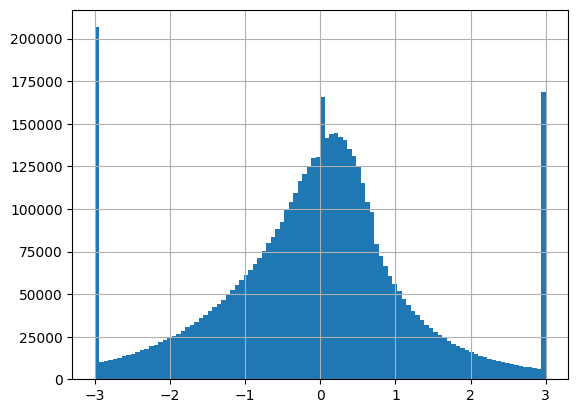

In [13]:
all_data['log_selection_factor_mod_zscore'].clip(upper=3, lower=-3).hist(bins=100)

### interim conclusions:
The only score that did not show an association with the original predictions is the modified z score.
The modified z score is calculated per measured position and amino acid. If we assume most other mutations do not interact epistatically with this position,
then the distribution of the measurements with all the pertubations should be a background noise distribution.
To find outliers that may be epistatic interaction, we use the modified z score, which used the median and is thus less affected by large outliers but can still identify them.

In [14]:
##### to do - add light chain to this as well (when light chain and paired models are available)

## Philips and shculz datasets

## aggregate data:
### per position pair
### per position+amino acid mutation and position
### per position+amino acid mutation

In [15]:
def heatmap_position_pairs_by_selection_diffs(all_data, cdr_positions=[], save_path=None):
    df = all_data[(all_data.mut_from_origin_pos != all_data.Position)].groupby(['mut_from_origin_pos', 'Position']).log_selection_factor_diff_abs.sum().reset_index()
    # Pivot the data to create a matrix suitable for a heatmap
    pivot_df = df.pivot(index="mut_from_origin_pos", columns="Position", values="log_selection_factor_diff_abs")
    # Plot the heatmap
    plt.figure(figsize=(14, 10))
    heatmap = sns.heatmap(pivot_df, cmap="Oranges", annot=False, xticklabels=True, yticklabels=True, cbar_kws={'label': 'Sum of Absolute Log Selection Factor Differences'})
    
    # Adjust x-axis labels - color CDR positions in red
    x_labels = heatmap.get_xticklabels()
    for label in x_labels:
        position = int(label.get_text())
        if position in cdr_positions:
            label.set_color('red')
    
    # Adjust y-axis labels - color CDR positions in red
    y_labels = heatmap.get_yticklabels()
    for label in y_labels:
        position = int(label.get_text())
        if position in cdr_positions:
            label.set_color('red')
    
    plt.xticks(rotation=90, fontsize=5)  # Rotate x labels 90 degrees and make them smaller
    plt.yticks(fontsize=5)  # Make y labels smaller
    heatmap.set_xticklabels(x_labels)
    heatmap.set_yticklabels(y_labels)
    plt.xlabel('Mutation for which selection factor was measured')
    plt.ylabel('Mutation perturbed')
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')

def heatmap_position_pairs_by_sign_flip(all_data, cdr_positions=[], save_path=None):
    df = all_data[(all_data.mut_from_origin_pos != all_data.Position)].groupby(['mut_from_origin_pos', 'Position']).div_pur_flip.sum().reset_index()
    # Pivot the data to create a matrix suitable for a heatmap
    pivot_df = df.pivot(index="mut_from_origin_pos", columns="Position", values="div_pur_flip")
    # Plot the heatmap
    plt.figure(figsize=(14, 10))
    heatmap = sns.heatmap(pivot_df, cmap="Oranges", annot=False, xticklabels=True, yticklabels=True, cbar_kws={'label': 'Count of Sign Flips'})
    
    # Adjust x-axis labels - color CDR positions in red
    x_labels = heatmap.get_xticklabels()
    for label in x_labels:
        position = int(label.get_text())
        if position in cdr_positions:
            label.set_color('red')
    
    # Adjust y-axis labels - color CDR positions in red
    y_labels = heatmap.get_yticklabels()
    for label in y_labels:
        position = int(label.get_text())
        if position in cdr_positions:
            label.set_color('red')
    
    plt.xticks(rotation=90, fontsize=5)  # Rotate x labels 90 degrees and make them smaller
    plt.yticks(fontsize=5)  # Make y labels smaller
    heatmap.set_xticklabels(x_labels)
    heatmap.set_yticklabels(y_labels)
    plt.xlabel('Mutation for which selection factor was measured')
    plt.ylabel('Mutation perturbed')
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')

def heatmap_position_pairs_by_zscore(all_data, cdr_positions=[], save_path=None):
    df = all_data[(all_data.mut_from_origin_pos != all_data.Position)].groupby(['mut_from_origin_pos', 'Position'])['log_selection_factor_mod_zscore_abs'].sum().reset_index()
    # Pivot the data to create a matrix suitable for a heatmap
    pivot_df = df.pivot(index="mut_from_origin_pos", columns="Position", values="log_selection_factor_mod_zscore_abs")
    # Plot the heatmap
    plt.figure(figsize=(14, 10))
    heatmap = sns.heatmap(pivot_df, cmap="Oranges", annot=False, xticklabels=True, yticklabels=True, cbar_kws={'label': 'Sum of Absolute Log Selection Factor z scores'})
    
    # Adjust x-axis labels - color CDR positions in red
    x_labels = heatmap.get_xticklabels()
    for label in x_labels:
        position = int(label.get_text())
        if position in cdr_positions:
            label.set_color('red')
    
    # Adjust y-axis labels - color CDR positions in red
    y_labels = heatmap.get_yticklabels()
    for label in y_labels:
        position = int(label.get_text())
        if position in cdr_positions:
            label.set_color('red')
    
    plt.xticks(rotation=90, fontsize=5)  # Rotate x labels 90 degrees and make them smaller
    plt.yticks(fontsize=5)  # Make y labels smaller
    heatmap.set_xticklabels(x_labels)
    heatmap.set_yticklabels(y_labels)
    plt.xlabel('Mutation for which selection factor was measured')
    plt.ylabel('Mutation perturbed')
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')

def barplot_measured_position_by_selection_diffs(all_data, cdr_positions=[], save_path=None):
    df = all_data[(all_data.mut_from_origin_pos != all_data.Position)].groupby(['Position']).log_selection_factor_diff_abs.sum().reset_index()
    # Create a bar plot
    plt.figure(figsize=(18, 4))
    ax = sns.barplot(x='Position', y='log_selection_factor_diff_abs', data=df)
    
    # Color x-axis labels red for CDR positions
    x_labels = ax.get_xticklabels()
    for label in x_labels:
        position = int(label.get_text())
        if position in cdr_positions:
            label.set_color('red')
        
    # Add labels and title
    plt.xlabel('Mutation for which selection factor was measured')
    plt.ylabel('Sum of |Log Selection Factor Differences|')
    plt.title('Total log selection factor changes measured in Each Position across All Pertubations')
    # Improve readability of x-axis labels
    plt.xticks(rotation=90)
    ax.set_xticklabels(x_labels)

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')

def barplot_measured_position_by_sign_flip(all_data, cdr_positions=[], save_path=None):
    df = all_data[(all_data.mut_from_origin_pos != all_data.Position)].groupby(['Position']).div_pur_flip.sum().reset_index()
    # Create a bar plot
    plt.figure(figsize=(18, 4))
    ax = sns.barplot(x='Position', y='div_pur_flip', data=df)
    
    # Color x-axis labels red for CDR positions
    x_labels = ax.get_xticklabels()
    for label in x_labels:
        position = int(label.get_text())
        if position in cdr_positions:
            label.set_color('red')
    
    # Add labels and title
    plt.xlabel('Mutation for which selection factor was measured')
    plt.ylabel('Count of Sign Flips')
    plt.title('Count of Sign Flips Measured in Each Position across All Pertubations')
    # Improve readability of x-axis labels
    plt.xticks(rotation=90)
    ax.set_xticklabels(x_labels)

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')

def barplot_mutated_position_by_selection_diffs(all_data, cdr_positions=[], save_path=None):
    df = all_data[(all_data.mut_from_origin_pos != all_data.Position)].groupby(['mut_from_origin_pos']).log_selection_factor_diff_abs.sum().reset_index()
    # Create a bar plot
    plt.figure(figsize=(18, 4))
    ax = sns.barplot(x='mut_from_origin_pos', y='log_selection_factor_diff_abs', data=df)
    
    # Color x-axis labels red for CDR positions
    x_labels = ax.get_xticklabels()
    for label in x_labels:
        position = int(label.get_text())
        if position in cdr_positions:
            label.set_color('red')
    
    # Add labels and title
    plt.xlabel('Mutated Position')
    plt.ylabel('Sum of |Log Selection Factor Differences|')
    plt.title('Total log selection factor changes for mutation originating in each position across all measurements')
    # Improve readability of x-axis labels
    plt.xticks(rotation=90)
    ax.set_xticklabels(x_labels)

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')

def barplot_mutated_position_by_sign_flip(all_data, cdr_positions=[], save_path=None):
    df = all_data[(all_data.mut_from_origin_pos != all_data.Position)].groupby(['mut_from_origin_pos']).div_pur_flip.sum().reset_index()
    # Create a bar plot
    plt.figure(figsize=(18, 4))
    ax = sns.barplot(x='mut_from_origin_pos', y='div_pur_flip', data=df)

    # Color x-axis labels red for CDR positions
    x_labels = ax.get_xticklabels()
    for label in x_labels:
        position = int(label.get_text())
        if position in cdr_positions:
            label.set_color('red')
    
    # Add labels and title
    plt.xlabel('Mutated Position')
    plt.ylabel('Count of Sign Flips')
    plt.title('Count of Sign Flips for Mutations Originating from Each Position')
    # Improve readability of x-axis labels
    plt.xticks(rotation=90)
    ax.set_xticklabels(x_labels)
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')


def test_mutations_of_interest(all_data, mutation_list, save_path=None):
    df = all_data.copy()
    df['measured_pos_aa'] = df.Position.astype(str) + df.AminoAcid
    mutation_list_reversed = [i[-1] + i[1:-1] + i[0] for i in mutation_list]
    df = df[(df.mut_from_origin.isin(mutation_list_reversed)) & 
            (df.measured_pos_aa.isin([i[1:] for i in mutation_list_reversed])) & 
            (df.mut_from_origin_pos != df.Position)]
    
    df.sort_values
    # Get the sort_order
    mut_from_origin_order = df.sort_values(['mut_from_origin_pos', 'mut_from_origin']).mut_from_origin.unique()
    measured_pos_aa_order = df.sort_values(['Position', 'measured_pos_aa']).measured_pos_aa.unique()
    
    # Make the pivot table normally (it will auto-sort alphabetically)
    pivot_df = df.pivot(index="mut_from_origin", columns="measured_pos_aa", values="log_selection_factor_diff")
    
    # Reindex to restore the desired order
    pivot_df = pivot_df.reindex(index=mut_from_origin_order, columns=measured_pos_aa_order)
    
    # Plot the heatmap
    plt.figure(figsize=(7, 5))
    heatmap = sns.heatmap(pivot_df, cmap="vlag", annot=False, 
                          xticklabels=True, yticklabels=True, 
                          cbar_kws={'label': 'Log Selection Factor Difference'}, 
                          center=0)
    
    plt.xlabel('Mutation for which selection factor was measured')
    plt.ylabel('Mutation perturbed')
    plt.title('Impact of Origin Mutations on Different Positions')
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')

def test_positions_of_interest(all_data, mutation_list):
    df = all_data.copy()
    position_list = [int(i[1:-1]) for i in mutation_list]
    df = df[(df.Position.isin(position_list)) & (df.mut_from_origin_pos.isin(position_list)) & (df.mut_from_origin_pos != df.Position)]
    
    # heatmap of log selection factor differences
    df2 = df.groupby(['mut_from_origin_pos', 'Position']).log_selection_factor_diff_abs.sum().reset_index()
    # Pivot the data to create a matrix suitable for a heatmap
    pivot_df = df2.pivot(index="mut_from_origin_pos", columns="Position", values="log_selection_factor_diff_abs")
    # Plot the heatmap
    plt.figure(figsize=(6, 4))
    heatmap = sns.heatmap(pivot_df, cmap="Oranges", annot=False, xticklabels=True, yticklabels=True, cbar_kws={'label': 'Sum of Absolute Log Selection Factor Differences'})
    # Adjust x-axis labels
    plt.xticks(rotation=90, fontsize=10)  # Rotate x labels 90 degrees and make them smaller
    plt.yticks(fontsize=10)  # Make y labels smaller
    plt.xlabel('Mutation for which selection factor was measured')
    plt.ylabel('Mutation perturbed')
    #heatmap of sign flips
    df2 = df.groupby(['mut_from_origin_pos', 'Position']).div_pur_flip.sum().reset_index()
    # Pivot the data to create a matrix suitable for a heatmap
    pivot_df = df2.pivot(index="mut_from_origin_pos", columns="Position", values="div_pur_flip")
    # Plot the heatmap
    plt.figure(figsize=(6, 4))
    heatmap = sns.heatmap(pivot_df, cmap="Oranges", annot=False, xticklabels=True, yticklabels=True, cbar_kws={'label': 'Count of Sign Flips'})
    # Adjust x-axis labels
    plt.xticks(rotation=90, fontsize=10)  # Rotate x labels 90 degrees and make them smaller
    plt.yticks(fontsize=10)  # Make y labels smaller    
    plt.xlabel('Mutation for which selection factor was measured')
    plt.ylabel('Mutation perturbed')
    # heatmap of modified z scores
    df2 = df.groupby(['mut_from_origin_pos', 'Position']).log_selection_factor_mod_zscore_abs.sum().reset_index()
    # Pivot the data to create a matrix suitable for a heatmap
    pivot_df = df2.pivot(index="mut_from_origin_pos", columns="Position", values="log_selection_factor_mod_zscore_abs")
    # Plot the heatmap
    plt.figure(figsize=(6, 4))
    heatmap = sns.heatmap(pivot_df, cmap="Oranges", annot=False, xticklabels=True, yticklabels=True, cbar_kws={'label': 'Sum of Absolute Log Selection Factor Modified Z-scores'})
    # Adjust x-axis labels
    plt.xticks(rotation=90, fontsize=10)  # Rotate x labels 90 degrees and make them smaller
    plt.yticks(fontsize=10)  # Make y labels smaller
    plt.xlabel('Mutation for which selection factor was measured')
    plt.ylabel('Mutation perturbed')

def test_mutations_of_interest_z_score(all_data, mutation_list, save_path=None):
    df = all_data.copy()
    df['measured_pos_aa'] = df.Position.astype(str) + df.AminoAcid
    mutation_list_reversed = [i[-1] + i[1:-1] + i[0] for i in mutation_list]
    df = df[(df.mut_from_origin.isin(mutation_list_reversed)) & 
            (df.measured_pos_aa.isin([i[1:] for i in mutation_list_reversed])) & 
            (df.mut_from_origin_pos != df.Position)]
    
    df.sort_values
    # Get the sort_order
    mut_from_origin_order = df.sort_values(['mut_from_origin_pos', 'mut_from_origin']).mut_from_origin.unique()
    measured_pos_aa_order = df.sort_values(['Position', 'measured_pos_aa']).measured_pos_aa.unique()
    
    # Make the pivot table normally (it will auto-sort alphabetically)
    pivot_df = df.pivot(index="mut_from_origin", columns="measured_pos_aa", values="log_selection_factor_mod_zscore")
    
    # Reindex to restore the desired order
    pivot_df = pivot_df.reindex(index=mut_from_origin_order, columns=measured_pos_aa_order)
    
    # Plot the heatmap
    plt.figure(figsize=(7, 5))
    heatmap = sns.heatmap(pivot_df, cmap="vlag", annot=False, 
                          xticklabels=True, yticklabels=True, 
                          cbar_kws={'label': 'log_selection_factor_mod_zscore'}, 
                          center=0)
    
    plt.xlabel('Mutation for which selection factor was measured')
    plt.ylabel('Mutation perturbed')
    plt.title('Impact of Origin Mutations on Different Positions')
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')

In [16]:

def get_numbering_dict(anarci_path, pcp_df=None, verbose=False, checks="imgt"):
    if anarci_path is None:
        return None

    numbering_dict = {}
    exclusion_dict = {}

    anarci_df = pd.read_csv(anarci_path)

    # assumes numbering starts at column 13 in ANARCI output
    numbering_cols = list(anarci_df.columns[13:])
    numbering_used = [False] * len(numbering_cols)

    for i, row in anarci_df.iterrows():
        sample_id = row["Id"]
        family = row["Id"]

        seqlist = [row[col] for col in numbering_cols]
        numbering = [nn for nn, aa in zip(numbering_cols, seqlist) if aa != "-"]

        if checks == "imgt":
            # For IMGT, numbered insertions can only be 111.* or 112.*.
            # Other numbered insertions come from ANARCI and the clonal family will be excluded
            exclude = False
            for nn in numbering:
                if "." in nn and nn[:3] != "111" and nn[:3] != "112":
                    exclusion_dict[(sample_id, family)] = (
                        f"Invalid IMGT insertion: {nn}"
                    )
                    if verbose == True:
                        print(f"Invalid IMGT insertion: {nn}", sample_id, family)
                    exclude = True
                    break
            if exclude == True:
                continue

        numbering_dict[(sample_id, family)] = numbering

        # keep track of which site numbers are used
        for nn in numbering:
            numbering_used[numbering_cols.index(nn)] = True

    # make a numbering reference of site numbers that are used
    numbering_dict[("reference", 0)] = [
        nn for nn, used in zip(numbering_cols, numbering_used) if used == True
    ]

    return (numbering_dict, exclusion_dict)

def get_cdr_positions(anarci_output_path):
    numbering_dict, exclusion_dict = get_numbering_dict(anarci_output_path)
    letter_num_dict = {'A':'1', 'B':'2', 'C':'3', 'D':'4', 'E':'5', 'F':'6', 'G':'7', 'H':'8', 'I':'9', 'J':'10', 'K':'11', 'L':'12', 'M':'13', 'N':'14', 'O':'15', 'P':'16', 'Q':'17', 'R':'18', 'S':'19', 'T':'20', 'U':'21', 'V':'22', 'W':'23', 'X':'24', 'Y':'25', 'Z':'26'}
    a = [i[:-1] + '.' + letter_num_dict[i[-1]]  if i[-1].isalpha() else i for i in list(numbering_dict.values())[0]]
    a = [int(float(i)) for i in a]
    CDR_positions = list(range(27, 39)) + list(range(56, 66)) + list(range(105, 118))
    #CDR1 27-38
    # CDR2 56-65
    # CDR3 105-117
    
    cdr = ['CDR' if i in CDR_positions else 'FR' for i in a]
    cdr = pd.DataFrame(cdr, columns=['CDR/FR']).reset_index()
    cdr['index'] = cdr.index + 1
    cdr.rename(columns={'index':'Position'}, inplace=True)
    cdr_positions = cdr[cdr['CDR/FR'] == 'CDR']['Position'].unique()
    return cdr_positions




In [17]:
#### philips dataset
philips_seq = 'EVQLVQSGAEVKKPGASVKVSCKASGYTFTDYHINWVRQAPGQGLEWMGWIHPNSGDTNYAQKFQGWVTMTRDTSISTAYMEVNGLKSDDTAVYYCARGGLEPRSVDYYYYGMDVWGQGTTVTVSS'
output_path = localify("DATA_DIR/epistasis/dasm_mutate_run/philips.csv")
mutation_list = ['G31D', 'Y33H', 'M34I', 'H35N', 'N52H', 'G57D', 'L83V', 'S84N', 'R85G', 'R87K']
cdr_positions = get_cdr_positions('/home/nharel/re/dasm-epistasis-experiments/_output/anarci_output_H_phillips.csv')


if not os.path.exists(output_path):
    all_data = run_model_mutating_seq(philips_seq, device='cuda')
    all_data.to_csv(output_path, index=False)

all_data = pd.read_csv(output_path)

all_data['div_pur_flip'] = (all_data['div_pur_flip']) & (all_data['log_selection_factor_diff_abs'] > 0.1)

#mc_dropout = run_mc_dropout_on_heavy_seq(philips_seq, "DASM_TRAINED_MODELS_DIR/dasm_4m-v1jaffeCC+v1tangCC-joint", dropout_prob=0.1)
#calc_mc_dropout_stats_per_seq(mc_dropout, quantiles=[0.025, 0.975])



/tmp/ipykernel_17640/84537670.py:113: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(x_labels)
/tmp/ipykernel_17640/84537670.py:137: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(x_labels)
/tmp/ipykernel_17640/84537670.py:161: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(x_labels)
/tmp/ipykernel_17640/84537670.py:185: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(x_labels)


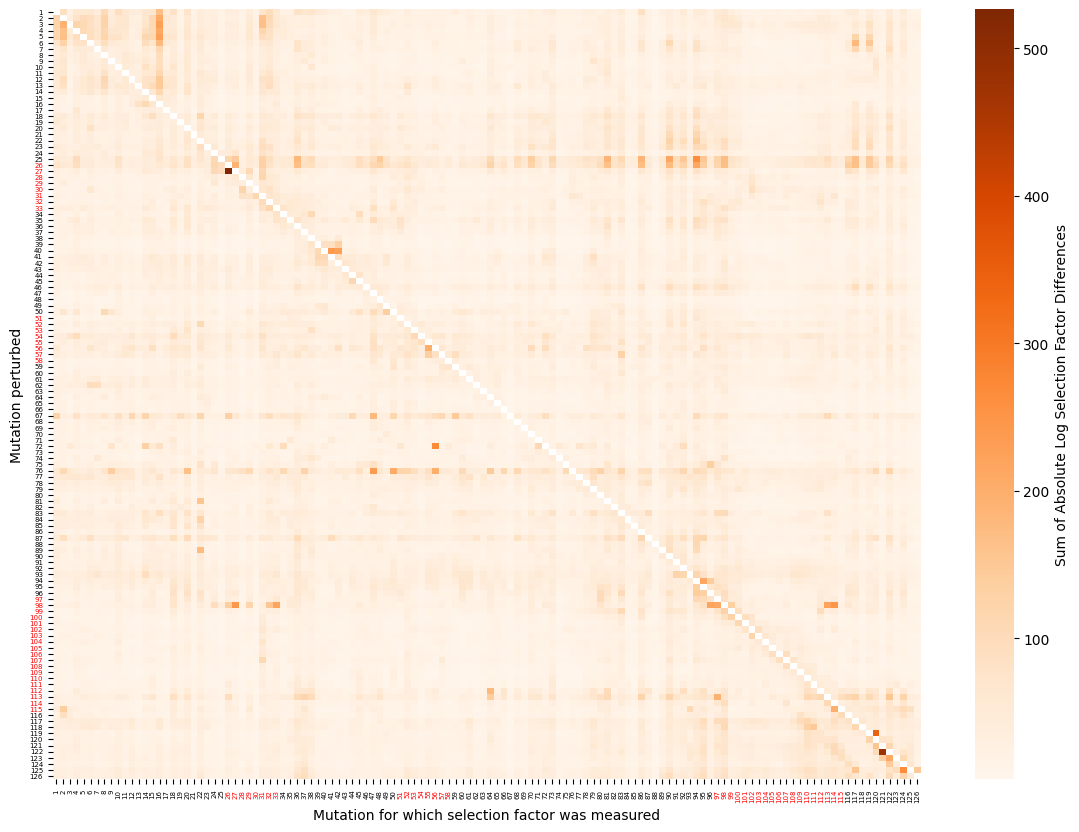

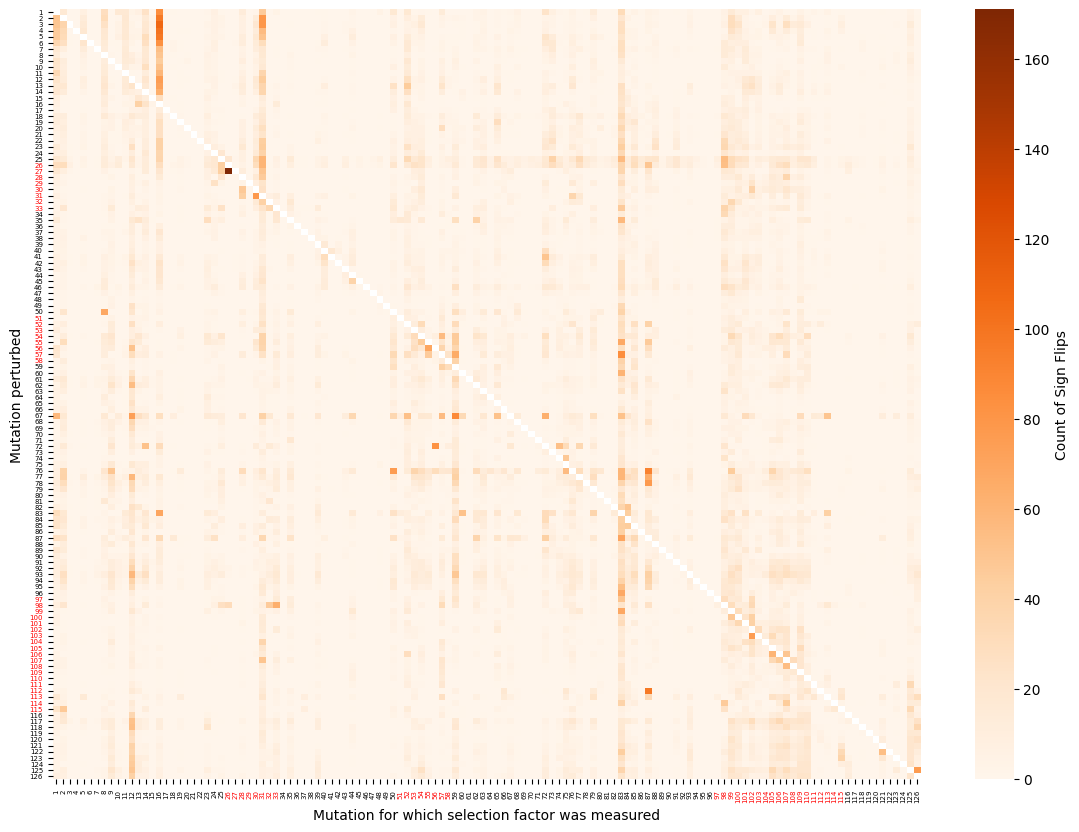

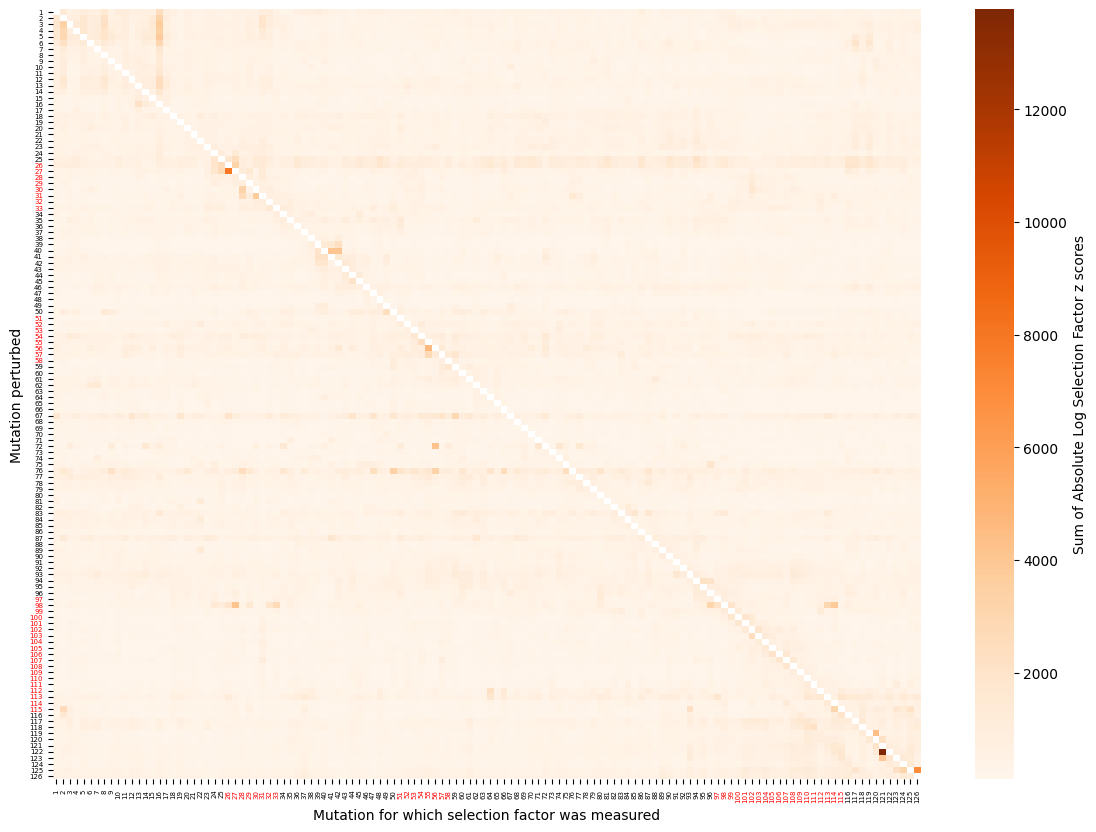

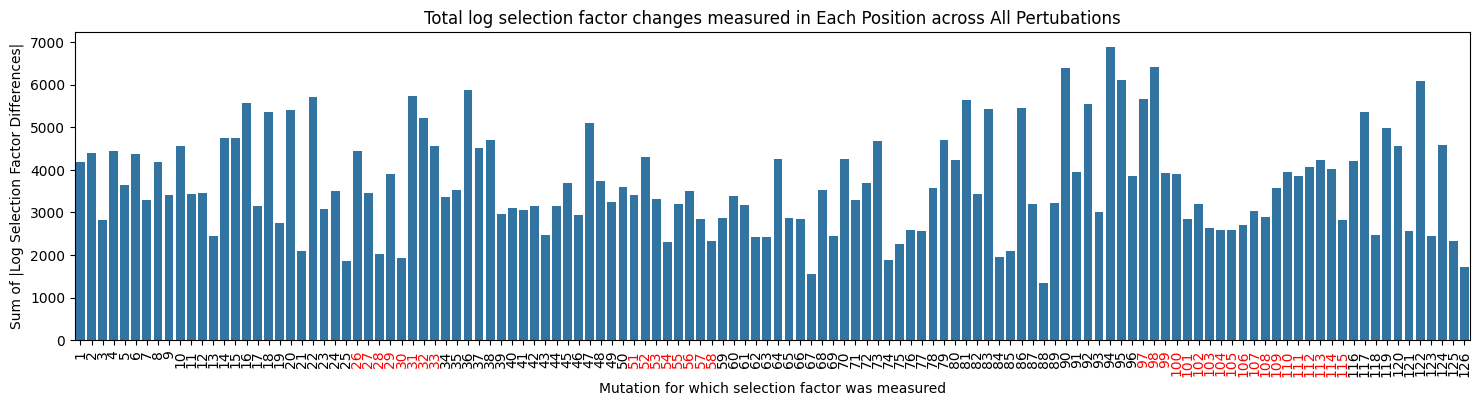

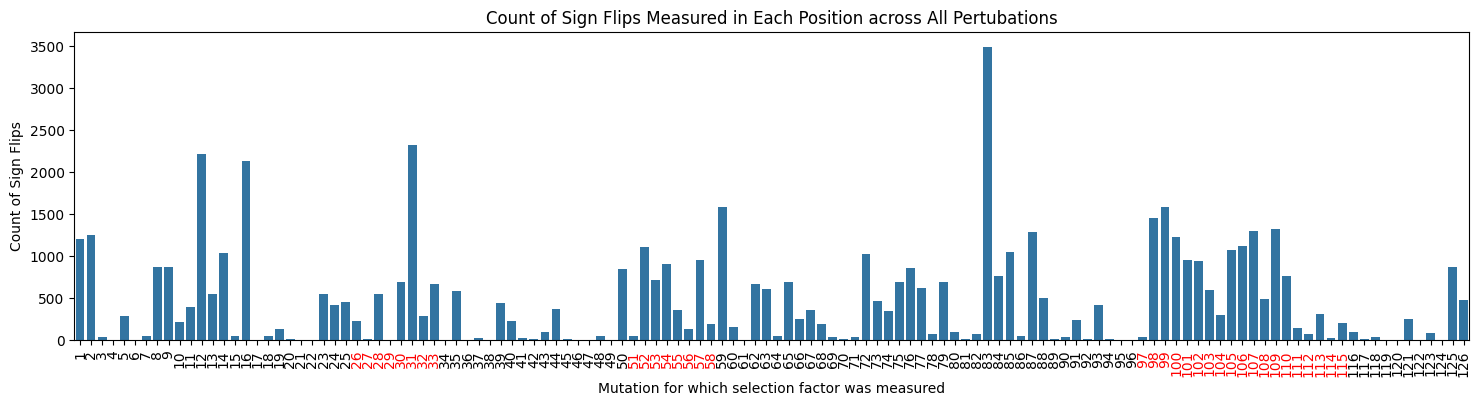

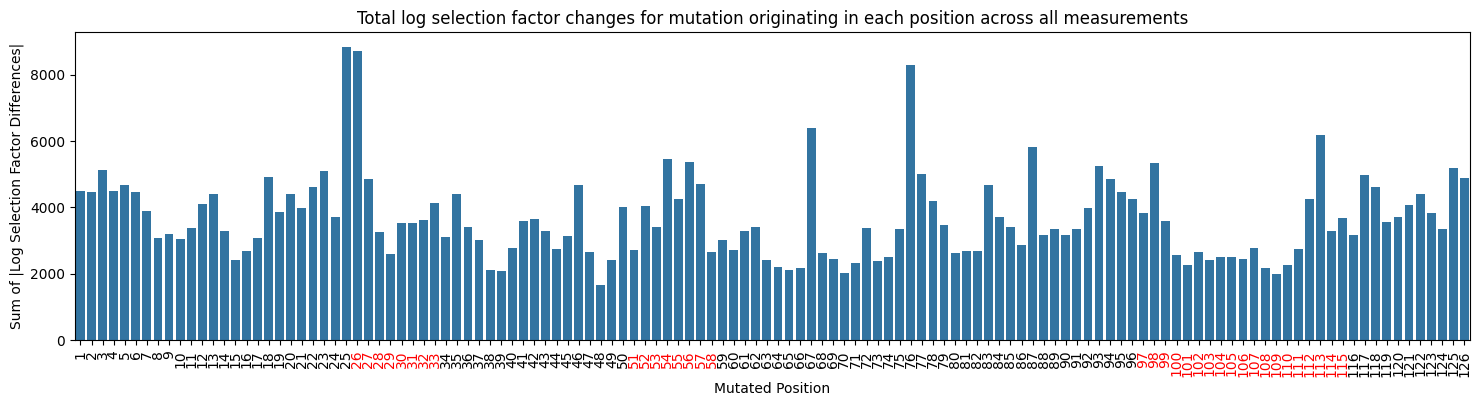

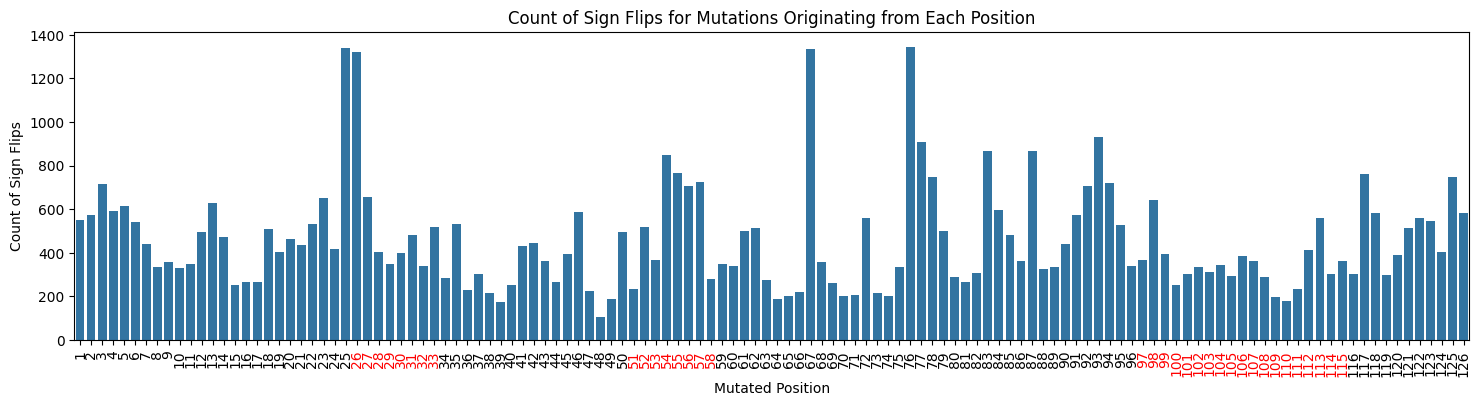

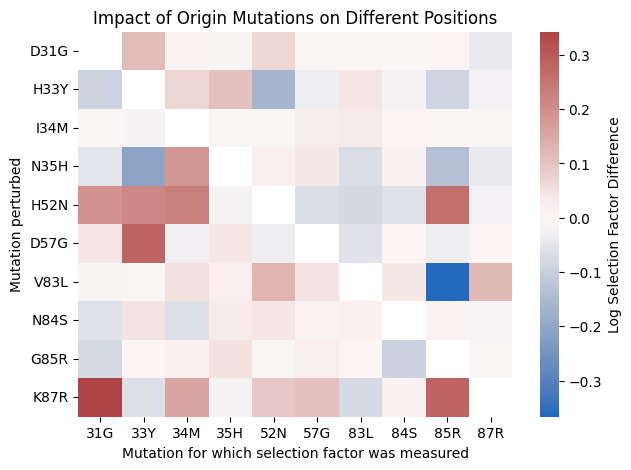

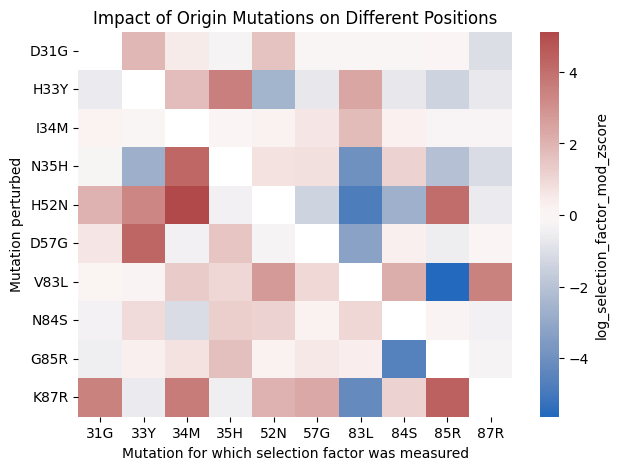

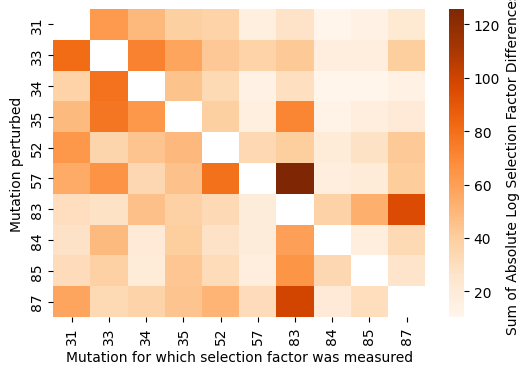

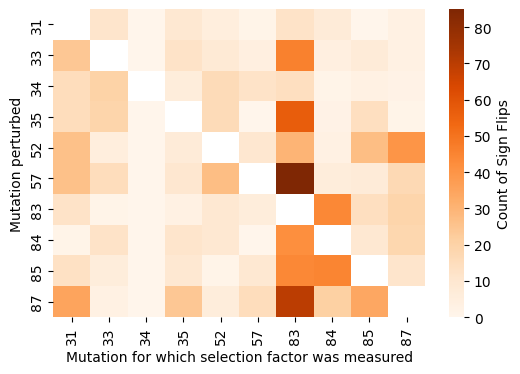

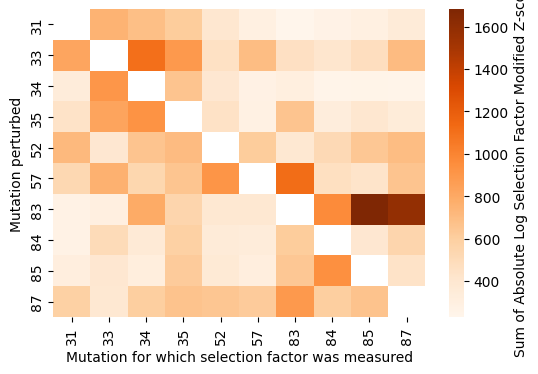

In [18]:
heatmap_position_pairs_by_selection_diffs(all_data, cdr_positions, save_path=localify("FIGURES_DIR/epistasis/philips_heatmap_selection_diffs.png"))
heatmap_position_pairs_by_sign_flip(all_data, cdr_positions, save_path=localify("FIGURES_DIR/epistasis/philips_heatmap_sign_flips.png"))
heatmap_position_pairs_by_zscore(all_data, cdr_positions)
barplot_measured_position_by_selection_diffs(all_data, cdr_positions, save_path=localify("FIGURES_DIR/epistasis/philips_barplot_measured_position_by_selection_diffs.png"))
barplot_measured_position_by_sign_flip(all_data, cdr_positions, save_path=localify("FIGURES_DIR/epistasis/philips_barplot_measured_position_by_sign_flip.png"))
barplot_mutated_position_by_selection_diffs(all_data, cdr_positions, save_path=localify("FIGURES_DIR/epistasis/philips_barplot_mutated_position_by_selection_diffs.png"))
barplot_mutated_position_by_sign_flip(all_data, cdr_positions, save_path=localify("FIGURES_DIR/epistasis/philips_barplot_mutated_position_by_sign_flip.png"))
test_mutations_of_interest(all_data, mutation_list, save_path=localify("FIGURES_DIR/epistasis/philips_heatmap_mutations_of_interest.png"))
test_mutations_of_interest_z_score(all_data, mutation_list)
test_positions_of_interest(all_data, mutation_list)




In [19]:
##  schulz data
schulz = 'EVQLVESGGGLIQPGGSLRLSCAASGFTVSSNYMSWVRQAPGKGLEWVSVIYSGGSTFYADSVKGRFTISRDNSKNTLYLQMNSLRAEDTAVYYCARDLGTGLFDYWGQGTLVTVSS'
output_path = localify("DATA_DIR/epistasis/dasm_mutate_run/schulz.csv")
mutation_list = ['Y58F', 'T28I', 'F27L', 'V50L', 'F27V', 'S35T', 'F27I', 'S31R', 'G26E', 'T57A', 'S56T', 'S53P', 'V50I']
mutation_list_reversed = [i[-1] + i[1:-1] + i[0] for i in mutation_list]
mutation_list = mutation_list + mutation_list_reversed
cdr_positions = get_cdr_positions('/home/nharel/re/dasm-epistasis-experiments/_output/anarci_output_H_schulz.csv')


if not os.path.exists(output_path):
    all_data = run_model_mutating_seq(schulz, device='cuda')
    all_data.to_csv(output_path, index=False)



all_data = pd.read_csv(output_path)
all_data['div_pur_flip'] = (all_data['div_pur_flip']) & (all_data['log_selection_factor_diff_abs'] > 0.1)


/tmp/ipykernel_17640/84537670.py:113: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(x_labels)
/tmp/ipykernel_17640/84537670.py:137: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(x_labels)
/tmp/ipykernel_17640/84537670.py:161: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(x_labels)
/tmp/ipykernel_17640/84537670.py:185: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(x_labels)


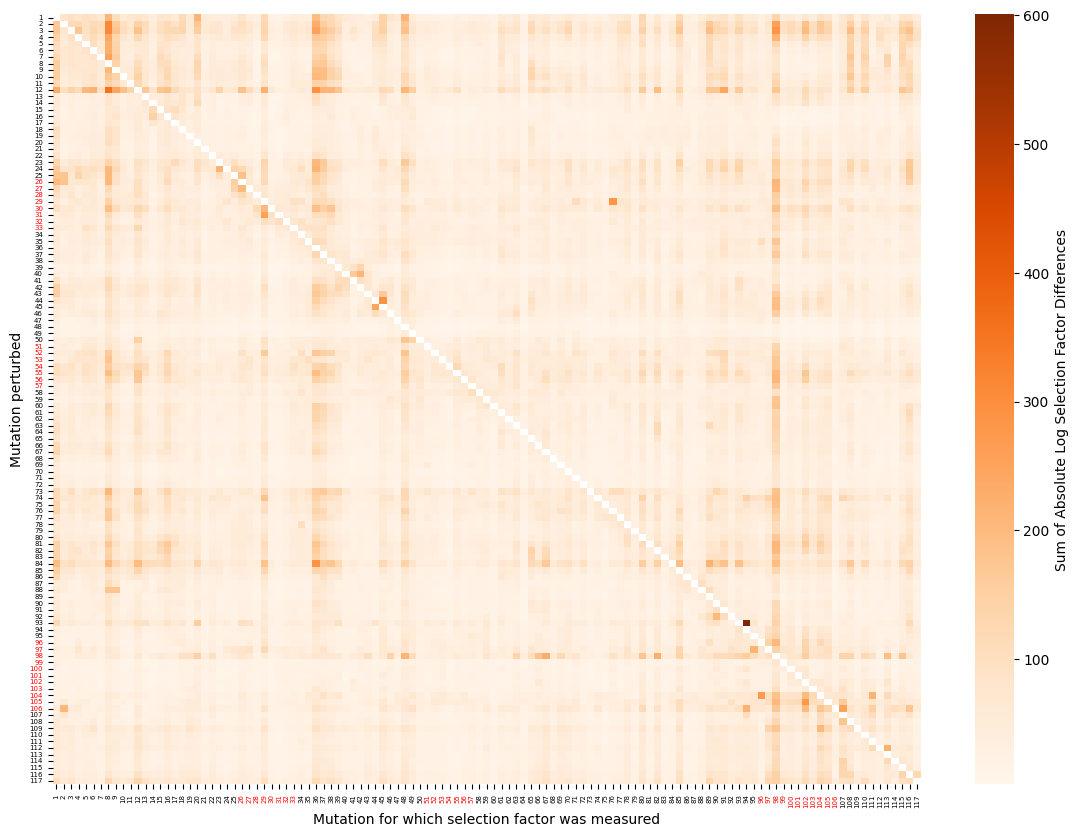

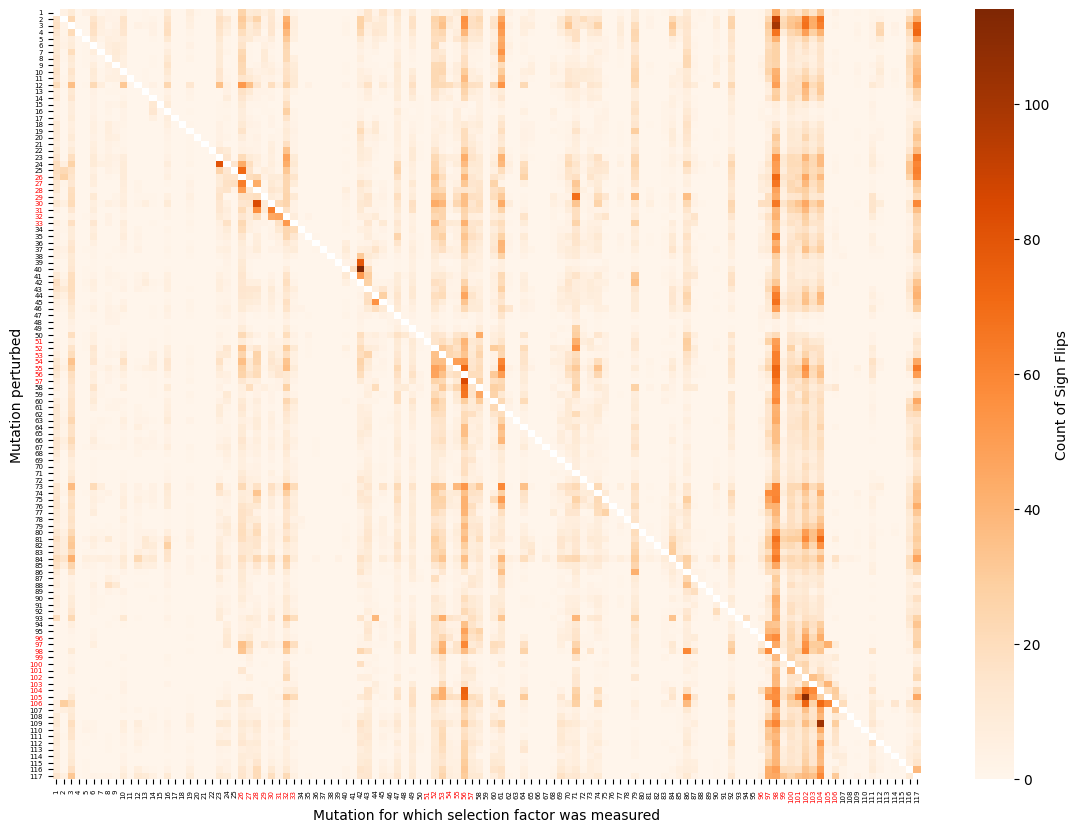

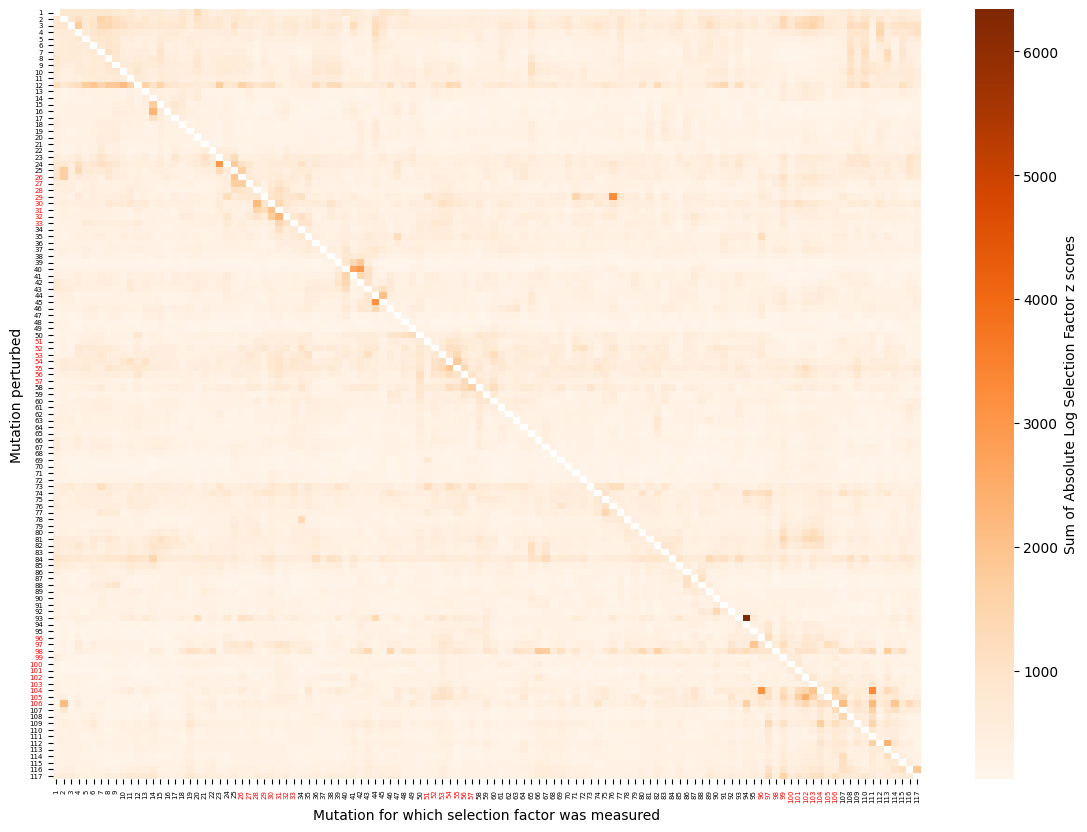

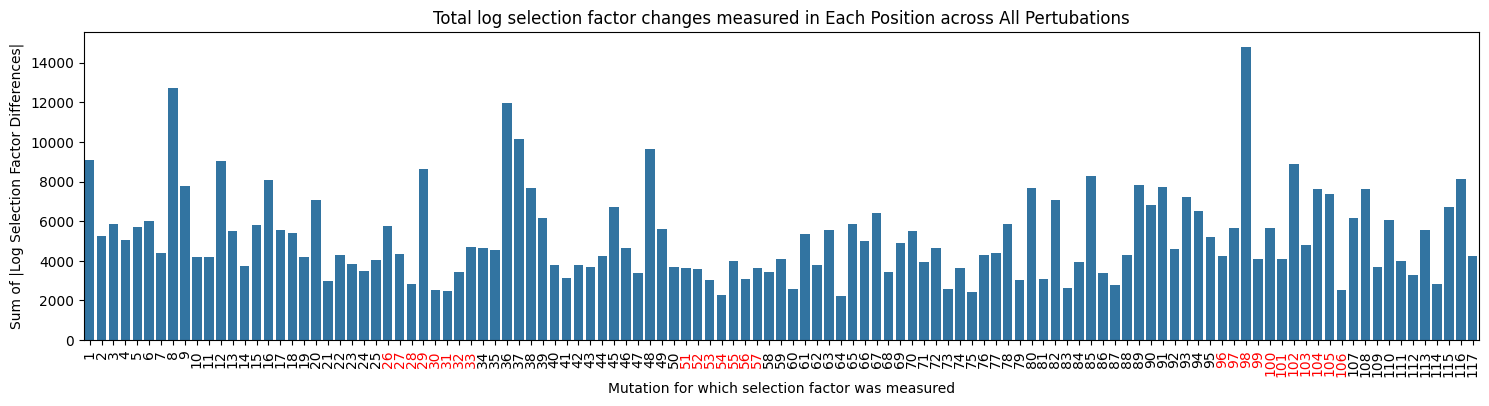

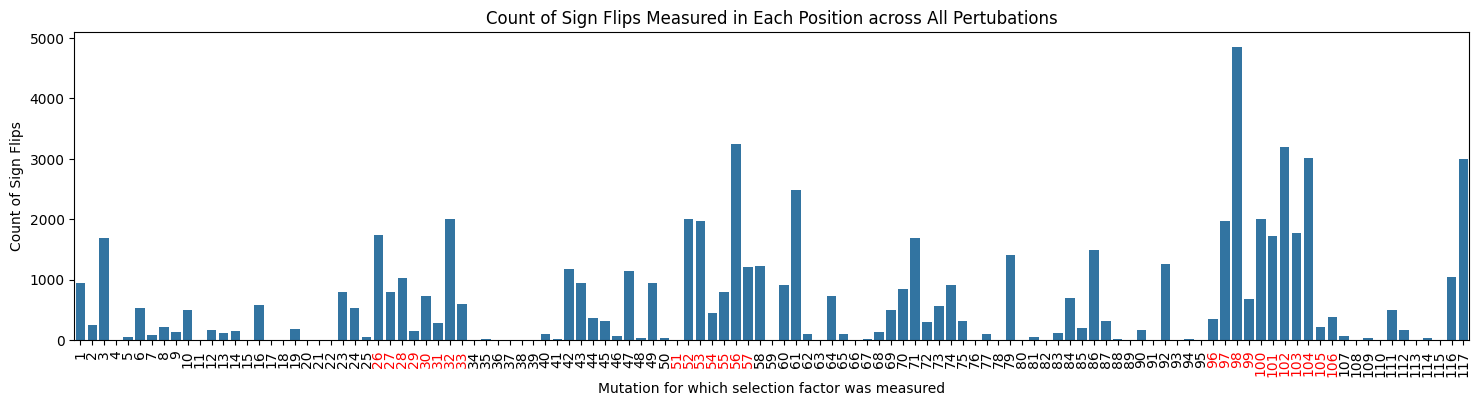

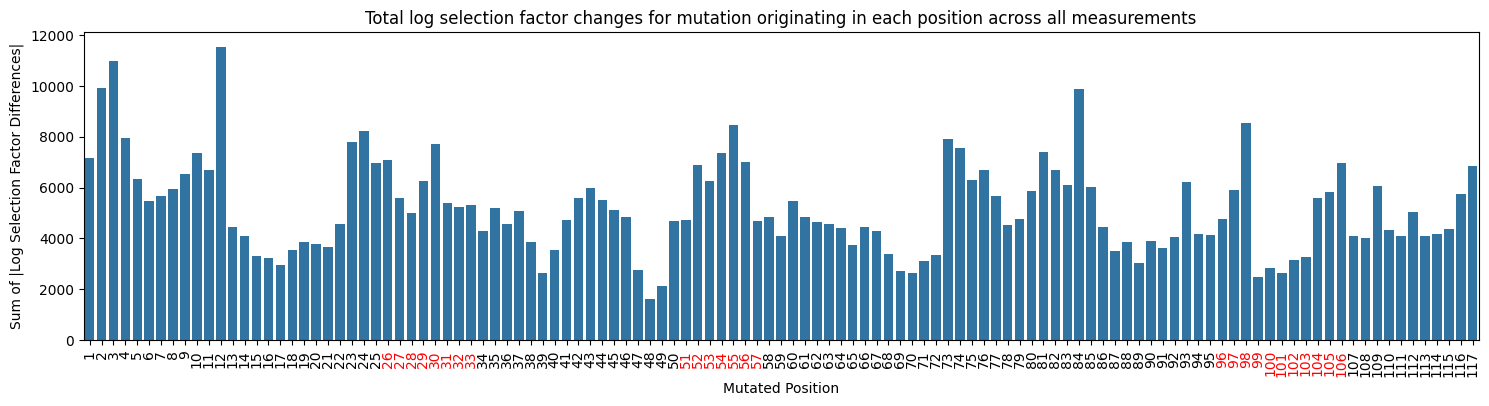

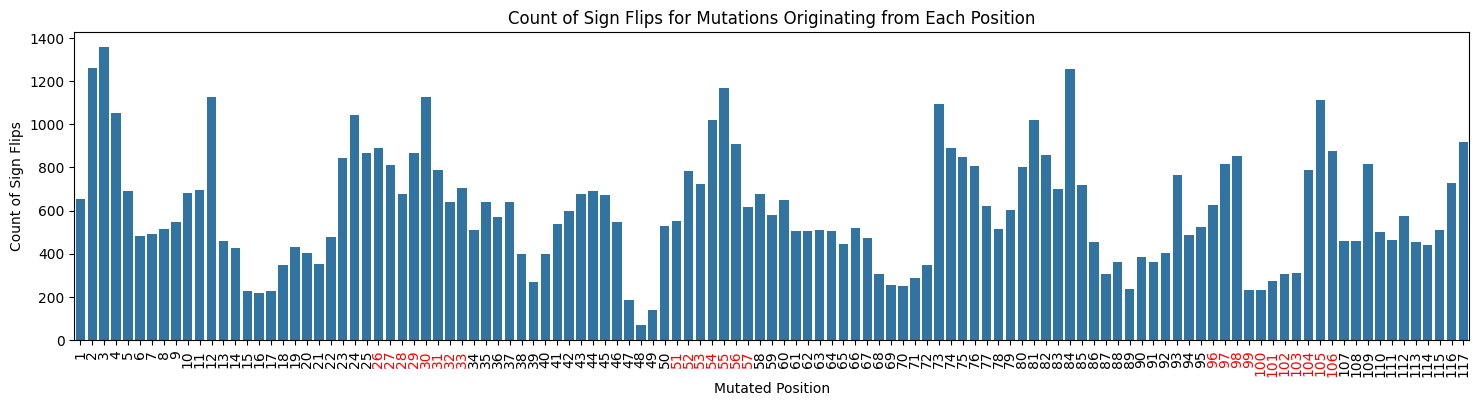

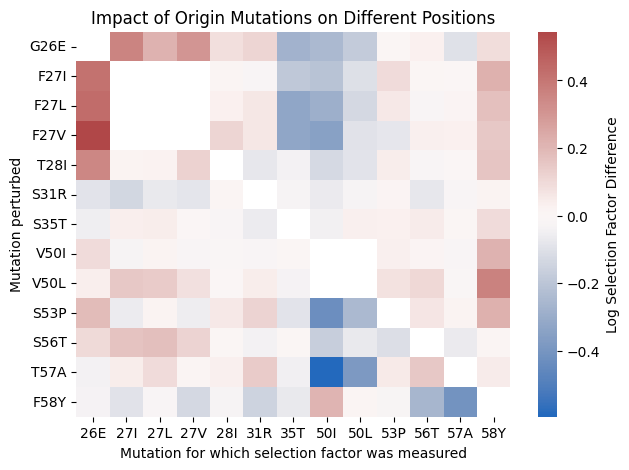

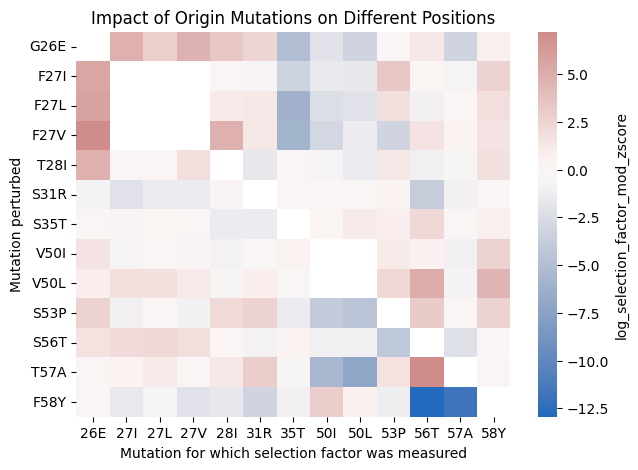

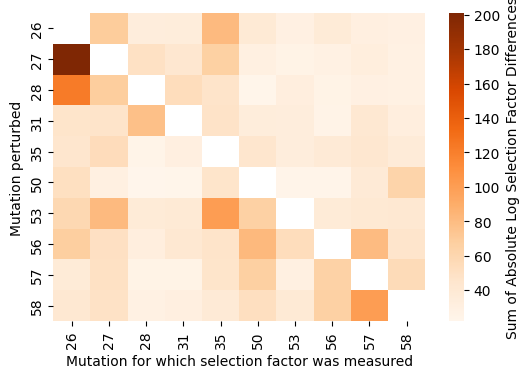

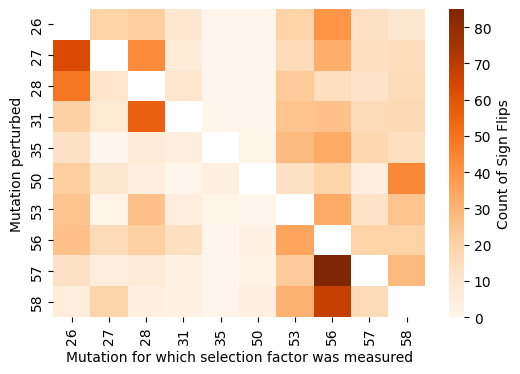

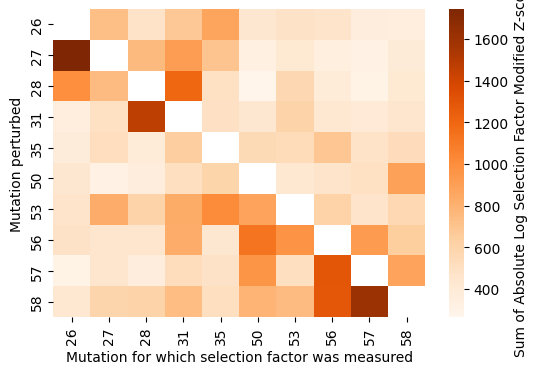

In [20]:
heatmap_position_pairs_by_selection_diffs(all_data, cdr_positions, save_path=localify("FIGURES_DIR/epistasis/schulz_heatmap_selection_diffs.png"))
heatmap_position_pairs_by_sign_flip(all_data, cdr_positions, save_path=localify("FIGURES_DIR/epistasis/schulz_heatmap_sign_flips.png"))
heatmap_position_pairs_by_zscore(all_data, cdr_positions)
barplot_measured_position_by_selection_diffs(all_data, cdr_positions, save_path=localify("FIGURES_DIR/epistasis/schulz_barplot_measured_position_by_selection_diffs.png"))
barplot_measured_position_by_sign_flip(all_data, cdr_positions, save_path=localify("FIGURES_DIR/epistasis/schulz_barplot_measured_position_by_sign_flip.png"))
barplot_mutated_position_by_selection_diffs(all_data, cdr_positions, save_path=localify("FIGURES_DIR/epistasis/schulz_barplot_mutated_position_by_selection_diffs.png"))
barplot_mutated_position_by_sign_flip(all_data, cdr_positions, save_path=localify("FIGURES_DIR/epistasis/schulz_barplot_mutated_position_by_sign_flip.png"))
test_mutations_of_interest(all_data, mutation_list, save_path=localify("FIGURES_DIR/epistasis/schulz_heatmap_mutations_of_interest.png"))
test_mutations_of_interest_z_score(all_data, mutation_list)
test_positions_of_interest(all_data, mutation_list)
